# AMC26 business entity resolution: exploratory data analysis

For each S1 record we must find its matching S2 and S3 records. Score is F0.5 per S1 record, averaged; an S1 with no true match scores 1.0 only if we predict nothing.

This notebook answers one question: **how far can fixed rules go, and where do we need string-similarity models or embeddings?**

Sections:
1. Data checks
2. Ground truth
3. Train vs test, France deep dive
4. Step-by-step clean-up of true pairs
5. Exact-match rules scored with the real metric
6. Candidate search: recall vs cost of each search key
7. Fuzzy features on a sample: hand rules vs best threshold vs gradient boosting
8. Embeddings vs char n-gram TF-IDF (needs PyTorch)
9. Duplicates inside S2/S3, ID and row-order leak checks
10. Decision table

Run from the project root (needs `dataset/`).

Charts and tables are shown inline and also saved to `eda_outputs/`. Headline numbers are collected in `FINDINGS` and written to `eda_outputs/findings.json` at the end.

In [1]:
import sys

# The Windows console is cp1252 and crashes on Hindi/Tamil text. Inside Jupyter, stdout is
# already UTF-8 (and has no reconfigure), so only switch when running as a plain script.
for _stream in (sys.stdout, sys.stderr):
    if hasattr(_stream, "reconfigure"):
        _stream.reconfigure(encoding="utf-8")

import gc
import json
import math
import os
import re
import time
import unicodedata
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import polars as pl
from anyascii import anyascii
from rapidfuzz import fuzz, process
from rapidfuzz.distance import JaroWinkler

ROOT = Path.cwd()
while not (ROOT / "dataset").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / "dataset"
OUT = ROOT / "eda_outputs"
OUT.mkdir(exist_ok=True)
SEED = 42
RNG = np.random.default_rng(SEED)
N_THREADS = os.cpu_count()

pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(70)
pl.Config.set_tbl_width_chars(220)
pl.Config.set_tbl_hide_dataframe_shape(True)

FINDINGS = {}  # headline numbers, written to eda_outputs/findings.json at the end


def save_table(df: pl.DataFrame, name: str, show: int | None = 40) -> None:
    """Write a table to eda_outputs/<name>.tsv (UTF-8) and print its head."""
    df.write_csv(OUT / f"{name}.tsv", separator="\t")
    if show:
        print(f"-> eda_outputs/{name}.tsv  ({df.height} rows)")
        print(df.head(show))


def save_fig(fig, name: str) -> None:
    fig.savefig(OUT / f"{name}.png", dpi=120, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"-> eda_outputs/{name}.png")


def write_text(name: str, text: str) -> None:
    with open(OUT / name, "w", encoding="utf-8", newline="\n") as f:
        f.write(text)
    print(f"-> eda_outputs/{name}")


class Timer:
    def __init__(self, label):
        self.label = label

    def __enter__(self):
        self.t0 = time.time()

    def __exit__(self, *exc):
        print(f"[{self.label}: {time.time() - self.t0:.1f}s]")


print("root:", ROOT)
print("polars", pl.__version__, "| numpy", np.__version__, "| threads", N_THREADS)

root: /mnt/vaultb/Soham/MLCSoham
polars 1.44.2 | numpy 2.5.3 | threads 40


## Load
All files are TSV with no quoting. Everything is read as strings. The source is added as a column from the ID prefix.

In [2]:
def read_tsv(path: Path) -> pl.DataFrame:
    return pl.read_csv(path, separator="\t", quote_char=None, infer_schema=False)


with Timer("load"):
    raw = {}
    for split in ("train", "test"):
        for s in (1, 2, 3):
            raw[(split, s)] = read_tsv(DATA / split / f"{split}_source{s}.tsv")
    gt_raw = read_tsv(DATA / "train" / "train_ground_truth.tsv")

for k, df in raw.items():
    print(k, df.shape, df.columns)
print("ground truth", gt_raw.shape, gt_raw.columns)

[load: 0.5s]
('train', 1) (2206821, 4) ['entity_id', 'business_name', 'business_address', 'country']
('train', 2) (5034616, 4) ['entity_id', 'business_name', 'business_address', 'country']
('train', 3) (5285603, 4) ['entity_id', 'business_name', 'business_address', 'country']
('test', 1) (1732544, 4) ['entity_id', 'business_name', 'business_address', 'country']
('test', 2) (4887273, 4) ['entity_id', 'business_name', 'business_address', 'country']
('test', 3) (5082316, 4) ['entity_id', 'business_name', 'business_address', 'country']
ground truth (2206821, 2) ['source1_entity_id', 'matched_entity_ids']


## 1. Data checks
Row counts, ID integrity, empty fields, script mix and text length per file. `pl.read_csv` turns empty fields into nulls, so "empty" below means null or whitespace-only.

In [3]:
SCRIPTS = {
    "Latin": r"\p{Latin}",
    "Devanagari": r"\p{Devanagari}",
    "Bengali": r"\p{Bengali}",
    "Gurmukhi": r"\p{Gurmukhi}",
    "Gujarati": r"\p{Gujarati}",
    "Oriya": r"\p{Oriya}",
    "Tamil": r"\p{Tamil}",
    "Telugu": r"\p{Telugu}",
    "Kannada": r"\p{Kannada}",
    "Malayalam": r"\p{Malayalam}",
    "Arabic": r"\p{Arabic}",
}
NONLATIN_RE = r"[^\p{Latin}\p{Common}\p{Inherited}]"  # any letter from a non-Latin script
NONASCII_RE = r"[^\x00-\x7F]"
TOKEN_RE = r"[\p{L}\p{M}\p{N}]+"  # keep \p{M}: Indic vowel signs are marks, dropping them shatters words

frames = []
for (split, s), df in raw.items():
    frames.append(df.with_columns(split=pl.lit(split), source=pl.lit(f"S{s}")))
recs = pl.concat(frames).with_columns(
    name=pl.col("business_name").fill_null(""),
    addr=pl.col("business_address").fill_null(""),
)
del frames, raw  # recs holds everything now
gc.collect()

overview = (
    recs.group_by("split", "source")
    .agg(
        rows=pl.len(),
        unique_ids=pl.col("entity_id").n_unique(),
        bad_prefix=(~pl.col("entity_id").str.starts_with(pl.col("source") + "-")).sum(),
        countries=pl.col("country").n_unique(),
        null_country=pl.col("country").is_null().sum(),
        empty_name_pct=(pl.col("name").str.strip_chars() == "").mean() * 100,
        empty_addr_pct=(pl.col("addr").str.strip_chars() == "").mean() * 100,
        dup_name_addr_pct=(1 - pl.struct("name", "addr", "country").n_unique() / pl.len()) * 100,
        name_len_med=pl.col("name").str.len_chars().median(),
        addr_len_med=pl.col("addr").str.len_chars().median(),
        name_nonlatin_pct=pl.col("name").str.contains(NONLATIN_RE).mean() * 100,
        addr_nonlatin_pct=pl.col("addr").str.contains(NONLATIN_RE).mean() * 100,
        name_nonascii_pct=pl.col("name").str.contains(NONASCII_RE).mean() * 100,
        has_tab_or_newline=(pl.col("name").str.contains(r"[\t\r\n]") | pl.col("addr").str.contains(r"[\t\r\n]")).sum(),
    )
    .sort("split", "source", descending=[True, False])
)
save_table(overview, "01_file_overview")

# every ID is unique across all files of a split (S1/S2/S3 prefixes cannot collide, but check the numbers too)
id_num = recs.with_columns(num=pl.col("entity_id").str.extract(r"-(\d+)$"))
print("IDs without a numeric part:", id_num["num"].is_null().sum())
print("numeric part reused across sources of one split (IDs are only unique with the prefix):",
      id_num.group_by("split", "num").agg(pl.col("source").n_unique().alias("k")).filter(pl.col("k") > 1).height)
print("IDs present in both train and test:",
      recs.filter(pl.col("split") == "train").join(recs.filter(pl.col("split") == "test"), on="entity_id").height)

-> eda_outputs/01_file_overview.tsv  (6 rows)
┌───────┬────────┬─────────┬────────────┬────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┬───────────────┬──────────────┬──────────────┬──────────────┐
│ split ┆ source ┆ rows    ┆ unique_ids ┆ bad_prefix ┆ countries ┆ null_country ┆ empty_name_pc ┆ empty_addr_pc ┆ dup_name_addr ┆ name_len_med ┆ addr_len_med ┆ name_nonlatin ┆ addr_nonlati ┆ name_nonasci ┆ has_tab_or_n │
│ ---   ┆ ---    ┆ ---     ┆ ---        ┆ ---        ┆ ---       ┆ ---          ┆ t             ┆ t             ┆ _pct          ┆ ---          ┆ ---          ┆ _pct          ┆ n_pct        ┆ i_pct        ┆ ewline       │
│ str   ┆ str    ┆ u32     ┆ u32        ┆ u32        ┆ u32       ┆ u32          ┆ ---           ┆ ---           ┆ ---           ┆ f64          ┆ f64          ┆ ---           ┆ ---          ┆ ---          ┆ ---          │
│       ┆        ┆         ┆            ┆            ┆           ┆    

In [4]:
script_rows = []
for col in ("name", "addr"):
    agg = {sc: pl.col(col).str.contains(rx).mean() * 100 for sc, rx in SCRIPTS.items()}
    agg["mixed_latin_and_other"] = (pl.col(col).str.contains(r"\p{Latin}") & pl.col(col).str.contains(NONLATIN_RE)).mean() * 100
    script_rows.append(recs.group_by("split", "source", "country").agg(**agg).with_columns(field=pl.lit(col)))
script_mix = pl.concat(script_rows).sort("field", "split", "country", "source", descending=[False, True, False, False])
save_table(script_mix.with_columns(pl.selectors.float().round(2)), "01_script_mix_pct")

-> eda_outputs/01_script_mix_pct.tsv  (30 rows)
┌───────┬────────┬─────────┬───────┬────────────┬─────────┬──────────┬──────────┬───────┬───────┬────────┬─────────┬───────────┬────────┬───────────────────────┬───────┐
│ split ┆ source ┆ country ┆ Latin ┆ Devanagari ┆ Bengali ┆ Gurmukhi ┆ Gujarati ┆ Oriya ┆ Tamil ┆ Telugu ┆ Kannada ┆ Malayalam ┆ Arabic ┆ mixed_latin_and_other ┆ field │
│ ---   ┆ ---    ┆ ---     ┆ ---   ┆ ---        ┆ ---     ┆ ---      ┆ ---      ┆ ---   ┆ ---   ┆ ---    ┆ ---     ┆ ---       ┆ ---    ┆ ---                   ┆ ---   │
│ str   ┆ str    ┆ str     ┆ f64   ┆ f64        ┆ f64     ┆ f64      ┆ f64      ┆ f64   ┆ f64   ┆ f64    ┆ f64     ┆ f64       ┆ f64    ┆ f64                   ┆ str   │
╞═══════╪════════╪═════════╪═══════╪════════════╪═════════╪══════════╪══════════╪═══════╪═══════╪════════╪═════════╪═══════════╪════════╪═══════════════════════╪═══════╡
│ train ┆ S1     ┆ India   ┆ 100.0 ┆ 0.0        ┆ 0.0     ┆ 0.0      ┆ 0.0      ┆ 0.0   ┆ 0.0   ┆ 0.0 

Examples of the noise named in the brief: junk wrappers, bracketed suffixes, legal suffix at the front, domains, "dba", fake accents, mixed scripts.

In [5]:
PATTERNS = {
    "junk_prefix (--, <<, |, #, *)": r"^\s*(--|<<|>>|\||\*|#|~|::)",
    "junk_suffix": r"(--|<<|>>|\||\*|~|::)\s*$",
    "bracketed [..] or (..)": r"[\[\(][^\]\)]*[\]\)]",
    "legal suffix first word": r"(?i)^\W*(llc|inc|ltd|pvt|corp|co|l\.l\.c\.|pllc|llp|limited|private)\b",
    "domain as name": r"(?i)^\S+\.(com|net|org|in|co|us|io|biz|info|fr)$",
    "www / http": r"(?i)(www\.|https?://)",
    "id or phone junk": r"(?i)\(id:\s*\d+\)|\b\d{7,}\b",
    "dba / aka / fka": r"(?i)\b(d/?b/?a|dba|a/?k/?a|f/?k/?a|t/a)\b",
    "repeated word": None,  # computed from tokens below (the regex engine has no backreferences)
    "latin accent": r"[À-ÖØ-öø-ÿĀ-ž]",
    "mixed script": None,
    "digit inside word (1ife)": r"\b[A-Za-z]+[0-9][A-Za-z]+\b",
}


def pattern_share(frame: pl.DataFrame) -> dict:
    out = {}
    n = pl.col("name")
    for label, rx in PATTERNS.items():
        if label == "repeated word":
            toks = n.str.to_lowercase().str.extract_all(TOKEN_RE)
            expr = toks.list.len() > toks.list.unique().list.len()
        elif label == "mixed script":
            expr = n.str.contains(r"\p{Latin}") & n.str.contains(NONLATIN_RE)
        else:
            expr = n.str.contains(rx)
        out[label] = expr
    return out


noise = (
    recs.group_by("split", "source", "country")
    .agg(**{k: v.mean() * 100 for k, v in pattern_share(recs).items()})
    .sort("split", "country", "source", descending=[True, False, False])
)
save_table(noise.with_columns(pl.selectors.float().round(2)), "01_name_noise_pct")

examples = []
for label, expr in pattern_share(recs).items():
    ex = recs.filter(expr & (pl.col("split") == "train")).sample(4, seed=SEED)
    examples.append(ex.select(pl.lit(label).alias("pattern"), "source", "country", "name", "addr"))
save_table(pl.concat(examples), "01_name_noise_examples", show=44)

-> eda_outputs/01_name_noise_pct.tsv  (15 rows)
┌───────┬────────┬─────────┬──────────────────┬─────────────┬────────────────────────┬──────────────┬────────────────┬────────────┬─────────────┬─────────────┬───────────────┬──────────────┬──────────────┬──────────────┐
│ split ┆ source ┆ country ┆ junk_prefix (--, ┆ junk_suffix ┆ bracketed [..] or (..) ┆ legal suffix ┆ domain as name ┆ www / http ┆ id or phone ┆ dba / aka / ┆ repeated word ┆ latin accent ┆ mixed script ┆ digit inside │
│ ---   ┆ ---    ┆ ---     ┆ <<, |, #, *)     ┆ ---         ┆ ---                    ┆ first word   ┆ ---            ┆ ---        ┆ junk        ┆ fka         ┆ ---           ┆ ---          ┆ ---          ┆ word (1ife)  │
│ str   ┆ str    ┆ str     ┆ ---              ┆ f64         ┆ f64                    ┆ ---          ┆ f64            ┆ f64        ┆ ---         ┆ ---         ┆ f64           ┆ f64          ┆ f64          ┆ ---          │
│       ┆        ┆         ┆ f64              ┆             ┆       

## 2. Ground truth
Matches per S1, singletons, unmatched S2/S3 records ("distractors"), whether one S2/S3 record can belong to two S1s, and whether matched pairs share a country.

true pairs: 7638365 | S2: 3693619 | S3: 3944746
GT S1 ids == S1 file ids: True
matched ids missing from S2/S3 files: 0
matched ids that belong to 2+ S1: 0
pairs whose countries differ: 0
-> eda_outputs/02_matches_per_s1_pct.tsv  (9 rows)
┌──────────┬───────┬───────┐
│ n_bucket ┆ India ┆ US    │
│ ---      ┆ ---   ┆ ---   │
│ str      ┆ f64   ┆ f64   │
╞══════════╪═══════╪═══════╡
│ 0        ┆ 5.59  ┆ 5.58  │
│ 1        ┆ 5.37  ┆ 5.42  │
│ 2        ┆ 16.98 ┆ 17.02 │
│ 3        ┆ 24.0  ┆ 24.09 │
│ 4        ┆ 21.93 ┆ 21.94 │
│ 5        ┆ 14.64 ┆ 14.55 │
│ 6        ┆ 7.53  ┆ 7.43  │
│ 7        ┆ 2.91  ┆ 2.89  │
│ 8+       ┆ 1.06  ┆ 1.07  │
└──────────┴───────┴───────┘
-> eda_outputs/02_cardinality.tsv  (2 rows)
┌─────────┬─────────┬───────────────┬──────────────┬────────────┬────────────┬───────────┬───────────┐
│ country ┆ s1      ┆ singleton_pct ┆ mean_matches ┆ s2_ge2_pct ┆ s3_ge2_pct ┆ no_s2_pct ┆ no_s3_pct │
│ ---     ┆ ---     ┆ ---           ┆ ---          ┆ ---        ┆ ---        

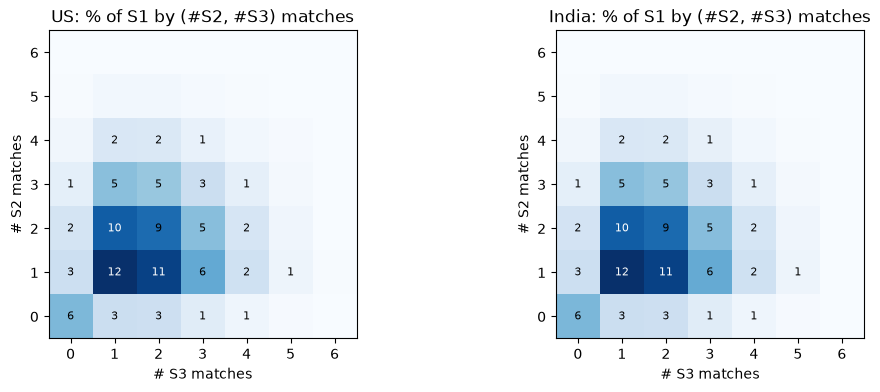

-> eda_outputs/02_s2_vs_s3_matches.png


In [6]:
train = recs.filter(pl.col("split") == "train")
s1_tr = train.filter(pl.col("source") == "S1").select(s1_id="entity_id", country="country")
cand_country = train.filter(pl.col("source") != "S1").select(m_id="entity_id", m_country="country")

pairs = (
    gt_raw.select(s1_id="source1_entity_id", m_id=pl.col("matched_entity_ids").str.split(","))
    .explode("m_id", empty_as_null=True)
    .drop_nulls("m_id")
    .with_columns(src=pl.col("m_id").str.slice(0, 2))
    .join(s1_tr, on="s1_id", how="left")
    .join(cand_country, on="m_id", how="left")
)
print("true pairs:", pairs.height, "| S2:", (pairs["src"] == "S2").sum(), "| S3:", (pairs["src"] == "S3").sum())
print("GT S1 ids == S1 file ids:", set(gt_raw["source1_entity_id"]) == set(s1_tr["s1_id"]))
print("matched ids missing from S2/S3 files:", pairs["m_country"].is_null().sum())
print("matched ids that belong to 2+ S1:", pairs.group_by("m_id").len().filter(pl.col("len") > 1).height)
print("pairs whose countries differ:", (pairs["country"] != pairs["m_country"]).sum())

per_s1 = s1_tr.join(
    pairs.group_by("s1_id").agg(n=pl.len(), n_s2=(pl.col("src") == "S2").sum(), n_s3=(pl.col("src") == "S3").sum()),
    on="s1_id",
    how="left",
).fill_null(0)

dist = (
    per_s1.with_columns(n_bucket=pl.when(pl.col("n") >= 8).then(pl.lit("8+")).otherwise(pl.col("n").cast(pl.String)))
    .group_by("country", "n_bucket")
    .len()
    .with_columns(pct=(pl.col("len") / pl.col("len").sum().over("country") * 100).round(2))
    .pivot(on="country", index="n_bucket", values="pct")
    .sort(pl.col("n_bucket").str.replace("8\\+", "8").cast(pl.Int32))
)
save_table(dist, "02_matches_per_s1_pct")
card = per_s1.group_by("country").agg(
    s1=pl.len(),
    singleton_pct=(pl.col("n") == 0).mean() * 100,
    mean_matches=pl.col("n").mean(),
    s2_ge2_pct=(pl.col("n_s2") >= 2).mean() * 100,
    s3_ge2_pct=(pl.col("n_s3") >= 2).mean() * 100,
    no_s2_pct=(pl.col("n_s2") == 0).mean() * 100,
    no_s3_pct=(pl.col("n_s3") == 0).mean() * 100,
)
save_table(card.with_columns(pl.selectors.float().round(2)), "02_cardinality")

distractors = (
    train.filter(pl.col("source") != "S1")
    .with_columns(matched=pl.col("entity_id").is_in(pairs["m_id"].implode()))
    .group_by("source", "country")
    .agg(records=pl.len(), unmatched_pct=(~pl.col("matched")).mean() * 100)
    .sort("source", "country")
)
save_table(distractors.with_columns(pl.col("unmatched_pct").round(2)), "02_unmatched_s2_s3")
FINDINGS["singleton_pct"] = round(float((per_s1["n"] == 0).mean() * 100), 2)
FINDINGS["mean_matches_per_s1"] = round(float(per_s1["n"].mean()), 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, c in zip(axes, ["US", "India"]):
    sub = per_s1.filter(pl.col("country") == c)
    h = sub.group_by("n_s2", "n_s3").len().filter((pl.col("n_s2") <= 6) & (pl.col("n_s3") <= 6))
    grid = np.zeros((7, 7))
    for a, b, v in h.iter_rows():
        grid[a, b] = v / sub.height * 100
    im = ax.imshow(grid, cmap="Blues", origin="lower")
    for (a, b), v in np.ndenumerate(grid):
        if v >= 0.5:
            ax.text(b, a, f"{v:.0f}", ha="center", va="center", fontsize=8, color="white" if v > 10 else "black")
    ax.set(title=f"{c}: % of S1 by (#S2, #S3) matches", xlabel="# S3 matches", ylabel="# S2 matches")
save_fig(fig, "02_s2_vs_s3_matches")

### The metric
`score()` is the exact per-S1 F0.5, macro-averaged over every S1 in the evaluation set, singletons included. It is reused for every rule and model below.

In [7]:
def score(pred: pl.DataFrame, truth: pl.DataFrame, universe: pl.DataFrame) -> dict:
    """pred/truth: (s1_id, m_id) pairs. universe: every evaluated S1 (column s1_id)."""
    pred = pred.select("s1_id", "m_id").unique()
    tp = pred.join(truth.select("s1_id", "m_id"), on=["s1_id", "m_id"], how="semi").group_by("s1_id").agg(tp=pl.len())
    per = (
        universe.select("s1_id")
        .join(pred.group_by("s1_id").agg(n_pred=pl.len()), on="s1_id", how="left")
        .join(truth.group_by("s1_id").agg(n_true=pl.len()), on="s1_id", how="left")
        .join(tp, on="s1_id", how="left")
        .fill_null(0)
        .with_columns(p=pl.col("tp") / pl.col("n_pred"), r=pl.col("tp") / pl.col("n_true"))
        .with_columns(
            f=pl.when((pl.col("n_true") == 0) & (pl.col("n_pred") == 0)).then(1.0)
            .when(pl.col("tp") == 0).then(0.0)
            .otherwise(1.25 * pl.col("p") * pl.col("r") / (0.25 * pl.col("p") + pl.col("r")))
        )
    )
    return {
        "f05": per["f"].mean(),
        "precision": per.filter(pl.col("n_pred") > 0)["p"].mean(),
        "recall": per.filter(pl.col("n_true") > 0)["r"].mean(),
        "singleton_acc": per.filter(pl.col("n_true") == 0)["f"].mean(),
        "multi_f05": per.filter(pl.col("n_true") >= 2)["f"].mean(),
        "pred_pairs": pred.height,
    }


# sanity check against the worked example in the problem statement (expected 0.714)
_t = pl.DataFrame({"s1_id": ["a", "a"], "m_id": ["x", "z"]})
_p = pl.DataFrame({"s1_id": ["a"] * 3, "m_id": ["x", "y", "z"]})
print("worked example:", round(score(_p, _t, pl.DataFrame({"s1_id": ["a"]}))["f05"], 3))


def f_counts(tp, npred, ntrue):
    p, r = tp / npred, tp / ntrue
    return pl.when((ntrue == 0) & (npred == 0)).then(1.0).when(tp == 0).then(0.0).otherwise(1.25 * p * r / (0.25 * p + r))


n, n2, n3 = pl.col("n"), pl.col("n_s2"), pl.col("n_s3")
zero = pl.lit(0)
whatif = {
    "predict nothing": f_counts(zero, zero, n),
    "exactly 1 correct per S1": f_counts(pl.min_horizontal(n, 1), pl.min_horizontal(n, 1), n),
    "1 correct per source (best S2 + best S3)": f_counts((n2 > 0).cast(int) + (n3 > 0).cast(int), (n2 > 0).cast(int) + (n3 > 0).cast(int), n),
    "all but one correct (miss 1 when n>=2)": f_counts(pl.when(n >= 2).then(n - 1).otherwise(n), pl.when(n >= 2).then(n - 1).otherwise(n), n),
    "all correct + 1 wrong on every S1": f_counts(n, n + 1, n),
    "all correct, 1 wrong only on singletons": f_counts(n, pl.when(n == 0).then(1).otherwise(n), n),
}
wi = per_s1.select(**{k: v.mean() for k, v in whatif.items()}).unpivot(variable_name="scenario", value_name="macro_f05")
save_table(wi.with_columns(pl.col("macro_f05").round(4)), "02_metric_what_if")

worked example: 0.714
-> eda_outputs/02_metric_what_if.tsv  (6 rows)
┌──────────────────────────────────────────┬───────────┐
│ scenario                                 ┆ macro_f05 │
│ ---                                      ┆ ---       │
│ str                                      ┆ f64       │
╞══════════════════════════════════════════╪═══════════╡
│ predict nothing                          ┆ 0.0558    │
│ exactly 1 correct per S1                 ┆ 0.6964    │
│ 1 correct per source (best S2 + best S3) ┆ 0.8574    │
│ all but one correct (miss 1 when n>=2)   ┆ 0.925     │
│ all correct + 1 wrong on every S1        ┆ 0.7515    │
│ all correct, 1 wrong only on singletons  ┆ 0.9442    │
└──────────────────────────────────────────┴───────────┘


## 3. Train vs test
Record counts per source and country, text-style profiles, and the share of S2/S3 records that have no S1 match. Test has no labels, so its unmatched share is estimated from train's matches per S1.

-> eda_outputs/03_counts_and_unmatched_share.tsv  (5 rows)
┌───────┬─────────┬─────────┬─────────┬─────────┬───────────┬───────────┬──────────────────────┬──────────────────────┐
│ split ┆ country ┆ S2      ┆ S1      ┆ S3      ┆ S2_per_S1 ┆ S3_per_S1 ┆ est_unmatched_S2_pct ┆ est_unmatched_S3_pct │
│ ---   ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---       ┆ ---       ┆ ---                  ┆ ---                  │
│ str   ┆ str     ┆ u32     ┆ u32     ┆ u32     ┆ f64       ┆ f64       ┆ f64                  ┆ f64                  │
╞═══════╪═════════╪═════════╪═════════╪═════════╪═══════════╪═══════════╪══════════════════════╪══════════════════════╡
│ train ┆ India   ┆ 2017799 ┆ 883188  ┆ 2115547 ┆ 2.28      ┆ 2.4       ┆ 26.63                ┆ 25.35                │
│ train ┆ US      ┆ 3016817 ┆ 1323633 ┆ 3170056 ┆ 2.28      ┆ 2.39      ┆ 26.64                ┆ 25.38                │
│ test  ┆ France  ┆ 703378  ┆ 259452  ┆ 731615  ┆ 2.71      ┆ 2.82      ┆ 38.25                ┆ 36.6

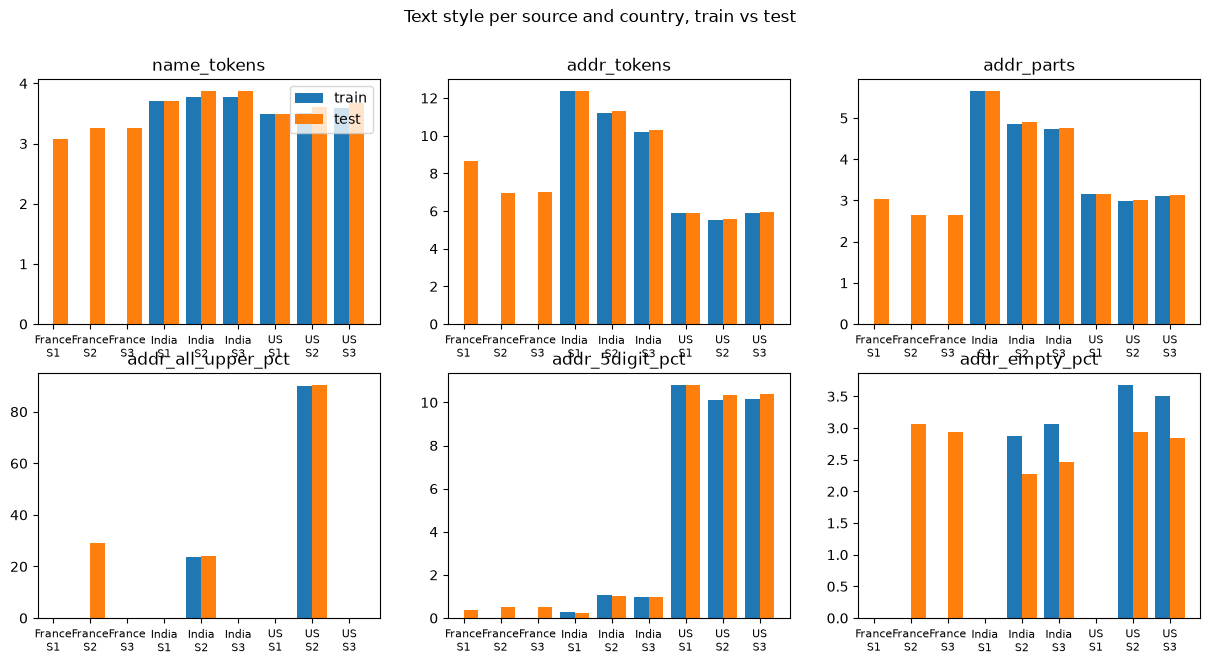

-> eda_outputs/03_style_profile.png


In [8]:
counts = recs.group_by("split", "source", "country").len().pivot(on="source", index=["split", "country"], values="len").sort("split", "country", descending=[True, False])
m2 = pairs.filter(pl.col("src") == "S2").group_by("country").len().rename({"len": "m2"})
m3 = pairs.filter(pl.col("src") == "S3").group_by("country").len().rename({"len": "m3"})
per_s1_rate = (
    counts.filter(pl.col("split") == "train").join(m2, on="country").join(m3, on="country")
    .select("country", r2=pl.col("m2") / pl.col("S1"), r3=pl.col("m3") / pl.col("S1"))
)
pooled = per_s1_rate.select(pl.col("r2", "r3").mean())  # France has no train rows: use the US/India average
shift = (
    counts.join(per_s1_rate, on="country", how="left")
    .with_columns(pl.col("r2").fill_null(pooled["r2"][0]), pl.col("r3").fill_null(pooled["r3"][0]))
    .with_columns(
        S2_per_S1=pl.col("S2") / pl.col("S1"),
        S3_per_S1=pl.col("S3") / pl.col("S1"),
        est_unmatched_S2_pct=(1 - pl.col("r2") * pl.col("S1") / pl.col("S2")) * 100,
        est_unmatched_S3_pct=(1 - pl.col("r3") * pl.col("S1") / pl.col("S3")) * 100,
    )
    .drop("r2", "r3")
)
save_table(shift.with_columns(pl.selectors.float().round(2)), "03_counts_and_unmatched_share")
FINDINGS["test_est_unmatched_S2_pct"] = {r["country"]: round(r["est_unmatched_S2_pct"], 1) for r in shift.filter(pl.col("split") == "test").iter_rows(named=True)}

nm, ad = pl.col("name"), pl.col("addr")
profile = (
    recs.group_by("split", "source", "country")
    .agg(
        name_tokens=nm.str.count_matches(TOKEN_RE).mean(),
        addr_tokens=ad.str.count_matches(TOKEN_RE).mean(),
        addr_parts=(ad.str.count_matches(",") + 1).mean(),
        name_all_upper_pct=(nm == nm.str.to_uppercase()).mean() * 100,
        addr_all_upper_pct=((ad == ad.str.to_uppercase()) & (ad != "")).mean() * 100,
        addr_5digit_pct=ad.str.contains(r"\b\d{5}\b").mean() * 100,
        addr_6digit_pct=ad.str.contains(r"\b\d{6}\b").mean() * 100,
        addr_starts_digit_pct=ad.str.contains(r"^\s*#*\d").mean() * 100,
        addr_has_digit_pct=ad.str.contains(r"\d").mean() * 100,
        addr_empty_pct=(ad.str.strip_chars() == "").mean() * 100,
    )
    .sort("country", "source", "split", descending=[False, False, True])
)
save_table(profile.with_columns(pl.selectors.float().round(2)), "03_style_profile", show=15)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
cols = ["name_tokens", "addr_tokens", "addr_parts", "addr_all_upper_pct", "addr_5digit_pct", "addr_empty_pct"]
groups = profile.select("source", "country").unique().sort("country", "source").rows()
x = np.arange(len(groups))
for ax, c in zip(axes.flat, cols):
    for i, sp in enumerate(["train", "test"]):
        vals = [profile.filter((pl.col("split") == sp) & (pl.col("source") == s) & (pl.col("country") == co))[c].to_list() for s, co in groups]
        ax.bar(x + (i - 0.5) * 0.4, [v[0] if v else np.nan for v in vals], 0.4, label=sp)
    ax.set_xticks(x, [f"{co}\n{s}" for s, co in groups], fontsize=8)
    ax.set_title(c)
axes[0, 0].legend()
fig.suptitle("Text style per source and country, train vs test")
save_fig(fig, "03_style_profile")

### France deep dive
France appears only in test. Samples per source, frequent tokens, legal forms and address abbreviations. Then likely pairs (S1 and S2/S3 records that share both a simple name key and a 5-digit postcode) show which noise patterns carry over.

In [9]:
fr = recs.filter(pl.col("country") == "France")
for s in ("S1", "S2", "S3"):
    print(f"--- France {s} sample")
    print(fr.filter(pl.col("source") == s).sample(8, seed=SEED).select("name", "addr"))


def top_tokens(frame: pl.DataFrame, col: str, k: int = 30) -> pl.DataFrame:
    return (
        frame.select(tok=pl.col(col).str.to_lowercase().str.extract_all(r"[\p{L}\p{M}\p{N}°º'.]+"))
        .explode("tok", empty_as_null=True).drop_nulls().group_by("tok").len().sort("len", descending=True).head(k)
    )


fr_tok = pl.concat(
    [top_tokens(fr.filter(pl.col("source") == s), col).select(pl.lit(f"{s}_{col}").alias("field"), "tok", "len")
     for col in ("name", "addr") for s in ("S1", "S2", "S3")]
)
save_table(fr_tok, "03_france_top_tokens", show=60)

FR_PATTERNS = {
    "SARL": r"(?i)\bs\.?a\.?r\.?l\b", "SAS/SASU": r"(?i)\bs\.?a\.?s\.?u?\b", "EURL": r"(?i)\beurl\b", "SA": r"(?i)\bs\.?a\b\.?",
    "SCI": r"(?i)\bsci\b", "& Fils / & Cie": r"(?i)&\s*(fils|cie)\b", "Ets/Établissements": r"(?i)\b(ets|établissements|etablissements)\b",
    "addr: rue": r"(?i)\brue\b", "addr: r / r.": r"(?i)\br\.?\s", "addr: bd / boulevard": r"(?i)\b(bd|boulevard)\b",
    "addr: av / avenue": r"(?i)\b(av|ave|avenue)\b\.?", "addr: n° / no": r"(?i)(n°|nº|\bno\.?\s*\d)", "addr: bis / ter": r"(?i)\b\d+\s*(bis|ter)\b",
    "addr: 5-digit postcode": r"\b\d{5}\b", "addr: CEDEX": r"(?i)\bcedex\b", "addr: region name": r"(?i)(île-de-france|ile-de-france|auvergne|provence|occitanie|nouvelle-aquitaine|bretagne|normandie|grand est|hauts-de-france|pays de la loire|bourgogne|centre-val)",
}
fr_pat = fr.group_by("source").agg(
    **{k: (pl.col("addr" if k.startswith("addr") else "name").str.contains(v)).mean() * 100 for k, v in FR_PATTERNS.items()}
).sort("source")
save_table(fr_pat.with_columns(pl.selectors.float().round(2)).transpose(include_header=True, column_names="source"), "03_france_patterns")


def simple_key(e: pl.Expr) -> pl.Expr:
    """lowercase, accents off, alnum tokens, legal words dropped, sorted: a crude key to find likely pairs."""
    toks = e.str.to_lowercase().str.normalize("NFKD").str.replace_all(r"[\x{0300}-\x{036f}]", "").str.extract_all(r"[a-z0-9]+")
    drop = ["sarl", "sas", "sasu", "eurl", "sa", "sci", "et", "cie", "fils", "inc", "llc", "ltd", "limited", "pvt", "private", "corp", "co", "the", "and", "of"]
    return toks.list.set_difference(pl.lit(drop)).list.sort().list.join(" ")


likely = (
    fr.filter(pl.col("source") == "S1").select("name", "addr", k=simple_key(pl.col("name")), pc=pl.col("addr").str.extract(r"\b(\d{5})\b"))
    .drop_nulls("pc")
    .join(fr.filter(pl.col("source") != "S1").select("source", name2="name", addr2="addr", k=simple_key(pl.col("name")), pc=pl.col("addr").str.extract(r"\b(\d{5})\b")), on=["k", "pc"])
    .filter(pl.col("k") != "")
)
print("likely France pairs (same simple name key + same postcode):", likely.height)
save_table(likely.sample(min(40, likely.height), seed=SEED).select("source", "name", "name2", "addr", "addr2"), "03_france_likely_pairs", show=20)

# How often does an S1 have an S2/S3 record with the same simple name key? Same statistic across splits and countries:
# if France behaves like US/India here, the same name clean-up carries over.
hit = []
for sp in ("train", "test"):
    sub = recs.filter(pl.col("split") == sp).with_columns(k=simple_key(pl.col("name")))
    keys23 = sub.filter(pl.col("source") != "S1").select("country", "k").unique()
    hit.append(sub.filter(pl.col("source") == "S1").join(keys23.with_columns(hit=pl.lit(True)), on=["country", "k"], how="left")
               .group_by("country").agg(s1_with_same_key_pct=pl.col("hit").is_not_null().mean() * 100).with_columns(split=pl.lit(sp)))
save_table(pl.concat(hit).sort("country", "split").with_columns(pl.col("s1_with_same_key_pct").round(2)), "03_same_key_rate_by_country")

--- France S1 sample
┌────────────────────────────┬──────────────────────────────────────────────────────────┐
│ name                       ┆ addr                                                     │
│ ---                        ┆ ---                                                      │
│ str                        ┆ str                                                      │
╞════════════════════════════╪══════════════════════════════════════════════════════════╡
│ Saint-Nazaire Parents SARL ┆ 80 Boulevard Albert 1er, Saint-Nazaire, Pays de la Loire │
│ Heart Comite SAS           ┆ Hauts-de-France, Roubaix, 191 Avenue Alfred Motte        │
│ XDS Amicale EURL           ┆ Nouvelle-Aquitaine, Bordeaux, 30 Rue Pierre              │
│ Aappma & Fils              ┆ 10 Rue Louis Aragon, Mérignac, Nouvelle-Aquitaine        │
│ Bordeaux Groupement SA     ┆ 90 Rue de la Louisiane, Bordeaux, Nouvelle-Aquitaine     │
│ Comité des Enfants         ┆ 21 Rue de Toulouse, Tourcoing, Hauts-de-France  

## 4. Step-by-step clean-up of true pairs
This is the main evidence for the normalization step. Each step is added on top of the previous ones. For every true (S1, S2/S3) pair we check whether the two cleaned strings are equal. The share that becomes equal shows how much each step buys, and what remains after the last rule is what fixed rules cannot reach.

First, what anyascii does to Indic names: the most frequent transliterated tokens. The legal-suffix spellings among them (praivet, limitet, elelpi…) go into the suffix list.

In [10]:
nonlatin_names = train.filter(pl.col("name").str.contains(NONLATIN_RE)).select("name").unique()
translit_tokens = (
    nonlatin_names.select(tok=pl.col("name").map_elements(anyascii, return_dtype=pl.String).str.to_lowercase().str.extract_all(r"[a-z0-9]+"))
    .explode("tok", empty_as_null=True).drop_nulls().group_by("tok").len().sort("len", descending=True)
)
save_table(translit_tokens.head(60), "04_translit_top_tokens", show=25)
print(nonlatin_names.sample(12, seed=SEED).with_columns(anyascii=pl.col("name").map_elements(anyascii, return_dtype=pl.String)))

-> eda_outputs/04_translit_top_tokens.tsv  (60 rows)
┌─────────────┬────────┐
│ tok         ┆ len    │
│ ---         ┆ ---    │
│ str         ┆ u32    │
╞═════════════╪════════╡
│ limited     ┆ 168149 │
│ praivet     ┆ 104555 │
│ li          ┆ 22500  │
│ pra         ┆ 22500  │
│ elelpi      ┆ 21954  │
│ limitet     ┆ 17146  │
│ praibhet    ┆ 17045  │
│ private     ┆ 14698  │
│ piraivet    ┆ 13590  │
│ limirrd     ┆ 11203  │
│ praivrr     ┆ 9117   │
│ tek         ┆ 8310   │
│ phuds       ┆ 7613   │
│ tredimg     ┆ 6900   │
│ globl       ┆ 6888   │
│ sri         ┆ 5846   │
│ lksmi       ┆ 5781   │
│ aiti        ┆ 5271   │
│ eksports    ┆ 5123   │
│ impeks      ┆ 5093   │
│ imjiniyrimg ┆ 4915   │
│ estet       ┆ 4890   │
│ al          ┆ 4777   │
│ phud        ┆ 4691   │
│ enrji       ┆ 4650   │
└─────────────┴────────┘
┌──────────────────────────────────────────┬──────────────────────────────────────────────┐
│ name                                     ┆ anyascii                           

### Normalization toolkit
Hand-written rules only. Tokens keep `\p{M}` so Indic words survive until transliteration.

In [11]:
LEGAL = [
    "inc", "incorporated", "corp", "corporation", "co", "company", "llc", "pllc", "ltd", "limited", "pvt", "private", "plc", "llp", "lp", "pc", "pa",
    "opc", "p", "the", "and", "of", "group",
    # anyascii spellings of प्राइवेट लिमिटेड / प्रा. लि. / एलएलपी and friends (table above)
    "praivet", "praibhet", "piraivet", "praivrr", "pra", "li", "limitet", "limirrd", "limtid", "elelpi",
    # French legal forms (test only)
    "sarl", "sas", "sasu", "eurl", "sa", "sci", "snc", "cie", "fils", "ets", "etablissements",
]
LEGAL_RE = r"\b(?:" + "|".join(LEGAL) + r")\b"
JUNK_RE = r"(?i)(www\.\S+|https?://\S+|\(id:\s*\d+\)|\bm/s\b|\b(?:d/?b/?a|a/?k/?a|f/?k/?a|t/a)\b|\b\d{7,}\b)"

US_STATES = {
    "alabama": "al", "alaska": "ak", "arizona": "az", "arkansas": "ar", "california": "ca", "colorado": "co", "connecticut": "ct", "delaware": "de",
    "district of columbia": "dc", "florida": "fl", "georgia": "ga", "hawaii": "hi", "idaho": "id", "illinois": "il", "indiana": "in", "iowa": "ia",
    "kansas": "ks", "kentucky": "ky", "louisiana": "la", "maine": "me", "maryland": "md", "massachusetts": "ma", "michigan": "mi", "minnesota": "mn",
    "mississippi": "ms", "missouri": "mo", "montana": "mt", "nebraska": "ne", "nevada": "nv", "new hampshire": "nh", "new jersey": "nj",
    "new mexico": "nm", "new york": "ny", "north carolina": "nc", "north dakota": "nd", "ohio": "oh", "oklahoma": "ok", "oregon": "or",
    "pennsylvania": "pa", "rhode island": "ri", "south carolina": "sc", "south dakota": "sd", "tennessee": "tn", "texas": "tx", "utah": "ut",
    "vermont": "vt", "virginia": "va", "washington": "wa", "west virginia": "wv", "wisconsin": "wi", "wyoming": "wy",
}
IN_STATES = {
    "maharashtra": "mh", "delhi": "dl", "uttar pradesh": "up", "karnataka": "ka", "tamil nadu": "tn", "west bengal": "wb", "gujarat": "gj",
    "telangana": "tg", "haryana": "hr", "rajasthan": "rj", "kerala": "kl", "keralam": "kl", "madhya pradesh": "mp", "bihar": "br",
    "andhra pradesh": "ap", "punjab": "pb", "odisha": "od", "orissa": "od", "goa": "ga", "assam": "as", "jharkhand": "jh",
    "chhattisgarh": "cg", "uttarakhand": "uk", "himachal pradesh": "hp", "jammu and kashmir": "jk", "chandigarh": "ch", "puducherry": "py",
}
NATIVE_STATES = {  # state names written in Indian scripts (hand-written)
    "महाराष्ट्र": "maharashtra", "दिल्ली": "delhi", "उत्तर प्रदेश": "uttar pradesh", "ಕರ್ನಾಟಕ": "karnataka", "தமிழ்நாடு": "tamil nadu",
    "পশ্চিমবঙ্গ": "west bengal", "ગુજરાત": "gujarat", "తెలంగాణ": "telangana", "हरियाणा": "haryana", "राजस्थान": "rajasthan", "കേരളം": "kerala",
    "बिहार": "bihar", "मध्य प्रदेश": "madhya pradesh", "ఆంధ్రప్రదేశ్": "andhra pradesh", "ਪੰਜਾਬ": "punjab", "ଓଡ଼ିଶା": "odisha",
}
ABBR = {  # canonical short forms; S2 sometimes expands ST to SAINT, so saint -> st too
    "street": "st", "saint": "st", "road": "rd", "avenue": "ave", "av": "ave", "drive": "dr", "lane": "ln", "court": "ct", "boulevard": "blvd",
    "bd": "blvd", "highway": "hwy", "parkway": "pkwy", "circle": "cir", "place": "pl", "square": "sq", "terrace": "ter", "trail": "trl",
    "suite": "ste", "apartment": "apt", "appt": "apt", "appartement": "apt", "floor": "fl", "flr": "fl", "building": "bldg", "north": "n",
    "south": "s", "east": "e", "west": "w", "mount": "mt", "fort": "ft", "point": "pt", "route": "rte", "rue": "r", "allee": "all",
    "number": "no", "near": "nr", "opposite": "opp", "sector": "sec", "house": "h", "hno": "h no", "road8": "rd 8",
}


def ws(e):
    return e.str.replace_all(r"\s+", " ").str.strip_chars()


def lower(e):
    return ws(e.str.to_lowercase())


def punct(e):
    return ws(e.str.replace_all("&", " and ").str.replace_all(r"['’`.]", "").str.replace_all(r"[^\p{L}\p{M}\p{N}]+", " "))


def fold(e):
    return e.str.normalize("NFKD").str.replace_all(r"[\x{0300}-\x{036f}]", "")


def word_map(e, mapping: dict):
    """replace whole words/phrases; longest phrases first, one pass (words are padded with double spaces)."""
    keys = sorted(mapping, key=len, reverse=True)
    padded = " " + e.str.replace_all(" ", "  ") + " "
    return ws(padded.str.replace_many([f" {k} " for k in keys], [f" {mapping[k]} " for k in keys]))


def sort_tokens(e):
    return e.str.split(" ").list.unique().list.sort().list.join(" ")


def to_ascii(col: str, pre_map: dict | None = None) -> pl.Expr:
    """anyascii, applied only to the non-ASCII strings (map built once per unique value)."""
    vals = train.select(pl.col(col).filter(pl.col(col).str.contains(NONASCII_RE)).unique()).to_series()
    if pre_map:
        vals_pre = vals.str.replace_many(list(pre_map), list(pre_map.values()))
    else:
        vals_pre = vals
    mapped = pl.Series([anyascii(v) for v in vals_pre.to_list()], dtype=pl.String)
    return pl.col(col).replace_strict(vals, mapped, default=pl.col(col))

In [12]:
with Timer("name steps"):
    ascii_name = to_ascii("name")
    NAME_STEPS = {
        "0 raw": pl.col("name"),
        "1 lowercase": lower(pl.col("name")),
        "2 punctuation": punct(lower(pl.col("name"))),
        "3 junk (www, ids, dba, m/s)": punct(lower(pl.col("name")).str.replace_all(JUNK_RE, " ")),
        "4 accents": fold(punct(lower(pl.col("name")).str.replace_all(JUNK_RE, " "))),
        "5 legal suffixes + stopwords": ws(fold(punct(lower(pl.col("name")).str.replace_all(JUNK_RE, " "))).str.replace_all(LEGAL_RE, " ")),
        "6 word order + repeats": sort_tokens(ws(fold(punct(lower(pl.col("name")).str.replace_all(JUNK_RE, " "))).str.replace_all(LEGAL_RE, " "))),
        "7 transliteration": sort_tokens(ws(fold(punct(lower(ascii_name).str.replace_all(JUNK_RE, " "))).str.replace_all(LEGAL_RE, " "))),
    }
    T = train.select("entity_id", "source", "country", "name", "addr").with_row_index("idx")
    name_keys = T.select(**{k: v for k, v in NAME_STEPS.items()})

idx = T.select("entity_id", "idx")
P = (
    pairs.join(idx.rename({"entity_id": "s1_id", "idx": "li"}), on="s1_id")
    .join(idx.rename({"entity_id": "m_id", "idx": "ri"}), on="m_id")
    .join(T.select(m_id="entity_id", cand_script=pl.when(pl.col("name").str.contains(NONLATIN_RE)).then(pl.lit("non-Latin")).otherwise(pl.lit("Latin"))), on="m_id")
    .select("s1_id", "m_id", "src", "country", "cand_script", "li", "ri")
)
li, ri = P["li"], P["ri"]

eq = {}
for step in NAME_STEPS:
    k = name_keys[step]
    eq[step] = (k.gather(li) == k.gather(ri))
final_name = name_keys["7 transliteration"]
with Timer("fuzzy"):
    tsr = process.cpdist(final_name.gather(li).to_list(), final_name.gather(ri).to_list(), scorer=fuzz.token_sort_ratio, workers=-1)
    tset = process.cpdist(final_name.gather(li).to_list(), final_name.gather(ri).to_list(), scorer=fuzz.token_set_ratio, workers=-1)
eq["8 fuzzy: token_sort >= 90"] = pl.Series(tsr >= 90) | eq["7 transliteration"]
eq["9 fuzzy: token_set >= 90"] = pl.Series(tset >= 90) | eq["8 fuzzy: token_sort >= 90"]
P = P.with_columns(name_tsr=pl.Series(tsr), name_tset=pl.Series(tset))


def staircase(eqd: dict, label: str) -> pl.DataFrame:
    frame = P.select("src", "country", "cand_script").with_columns(**{k: v for k, v in eqd.items()})
    parts = [frame.select(pl.lit("all").alias("group"), *[(pl.col(k).mean() * 100).alias(k) for k in eqd])]
    for g in ("country", "src", "cand_script"):
        parts.append(frame.group_by(g).agg(*[(pl.col(k).mean() * 100).alias(k) for k in eqd]).select(pl.concat_str(pl.lit(f"{g}="), pl.col(g)).alias("group"), *eqd))
    out = pl.concat(parts).unpivot(index="group", variable_name="step", value_name="pct_equal").pivot(on="group", index="step", values="pct_equal")
    save_table(out.with_columns(pl.selectors.float().round(2)), label, show=20)
    return out


name_stair = staircase(eq, "04_name_staircase")
FINDINGS["name_equal_after_rules_pct"] = round(float(name_stair.filter(pl.col("step") == "7 transliteration")["all"][0]), 2)
FINDINGS["name_equal_after_fuzzy90_pct"] = round(float(name_stair.filter(pl.col("step") == "9 fuzzy: token_set >= 90")["all"][0]), 2)

[name steps: 40.2s]
[fuzzy: 3.7s]
-> eda_outputs/04_name_staircase.tsv  (10 rows)
┌──────────────────────────────┬───────┬───────────────┬────────────┬────────┬────────┬───────────────────────┬───────────────────┐
│ step                         ┆ all   ┆ country=India ┆ country=US ┆ src=S2 ┆ src=S3 ┆ cand_script=non-Latin ┆ cand_script=Latin │
│ ---                          ┆ ---   ┆ ---           ┆ ---        ┆ ---    ┆ ---    ┆ ---                   ┆ ---               │
│ str                          ┆ f64   ┆ f64           ┆ f64        ┆ f64    ┆ f64    ┆ f64                   ┆ f64               │
╞══════════════════════════════╪═══════╪═══════════════╪════════════╪════════╪════════╪═══════════════════════╪═══════════════════╡
│ 0 raw                        ┆ 4.64  ┆ 2.71          ┆ 5.92       ┆ 4.73   ┆ 4.55   ┆ 0.0                   ┆ 5.0               │
│ 1 lowercase                  ┆ 15.77 ┆ 10.88         ┆ 19.04      ┆ 15.64  ┆ 15.89  ┆ 0.0                   ┆ 17.0          

Which tokens still differ inside true pairs after steps 0 to 4 (legal words kept)? Tokens only on the S1 side, and tokens only on the S2/S3 side. This list decides what the suffix and abbreviation dictionaries must contain.

In [13]:
samp = P.sample(1_000_000, seed=SEED)
k4 = name_keys["4 accents"]
toks_l = k4.gather(samp["li"]).str.split(" ")
toks_r = k4.gather(samp["ri"]).str.split(" ")
diff = pl.DataFrame({"only_s1": toks_l.list.set_difference(toks_r), "only_cand": toks_r.list.set_difference(toks_l)})
tok_diff = pl.concat(
    [
        diff.select(tok="only_s1").explode("tok", empty_as_null=True).drop_nulls().group_by("tok").len().sort("len", descending=True).head(50).rename({"tok": "only_in_s1", "len": "n_s1"}),
        diff.select(tok="only_cand").explode("tok", empty_as_null=True).drop_nulls().group_by("tok").len().sort("len", descending=True).head(50).rename({"tok": "only_in_candidate", "len": "n_cand"}),
    ],
    how="horizontal",
)
save_table(tok_diff, "04_name_token_differences", show=30)

-> eda_outputs/04_name_token_differences.tsv  (50 rows)
┌───────────────┬────────┬───────────────────┬────────┐
│ only_in_s1    ┆ n_s1   ┆ only_in_candidate ┆ n_cand │
│ ---           ┆ ---    ┆ ---               ┆ ---    │
│ str           ┆ u32    ┆ str               ┆ u32    │
╞═══════════════╪════════╪═══════════════════╪════════╡
│ limited       ┆ 130673 ┆ ltd               ┆ 32747  │
│ private       ┆ 79238  ┆ center            ┆ 30880  │
│ llc           ┆ 52813  ┆ लिमिटेड            ┆ 29035  │
│ inc           ┆ 39481  ┆ प्राइवेट            ┆ 24492  │
│ ltd           ┆ 30789  ┆ services          ┆ 21638  │
│ pvt           ┆ 16024  ┆ inc               ┆ 13775  │
│ and           ┆ 13836  ┆ service           ┆ 10479  │
│ pc            ┆ 9181   ┆ co                ┆ 9358   │
│ llp           ┆ 7636   ┆ corporation       ┆ 8744   │
│ group         ┆ 6473   ┆ the               ┆ 8624   │
│ care          ┆ 6360   ┆ corp              ┆ 8454   │
│ corp          ┆ 5884   ┆ partners          

/tmp/ipykernel_2035706/3276721951.py:6: DeprecationWarning: the default behavior of `how='horizontal'` for `concat` is deprecated and will require equal heights in the next breaking release. Use `how='horizontal_extend'` to keep the current behavior.
(Deprecated in version 1.42.1)
  tok_diff = pl.concat(


What is left after all rules and fuzzy matching: true pairs whose final token_set score is still below 80.

-> eda_outputs/04_name_residual_share.tsv  (4 rows)
┌─────────┬─────┬────────────────────────┐
│ country ┆ src ┆ pct_name_tset_below_80 │
│ ---     ┆ --- ┆ ---                    │
│ str     ┆ str ┆ f64                    │
╞═════════╪═════╪════════════════════════╡
│ India   ┆ S2  ┆ 27.38                  │
│ India   ┆ S3  ┆ 22.45                  │
│ US      ┆ S2  ┆ 10.91                  │
│ US      ┆ S3  ┆ 10.8                   │
└─────────┴─────┴────────────────────────┘
-> eda_outputs/04_name_residual_examples.tsv  (60 rows)
┌─────────┬─────┬───────────┬─────────────────────────────────────────┬────────────────────────────────────────┬─────────────────────────────────────────────────────┬─────────────────────────────────────────────────────┐
│ country ┆ src ┆ name_tset ┆ ln                                      ┆ rn                                     ┆ la                                                  ┆ ra                                                  │
│ ---     ┆ --- ┆ --

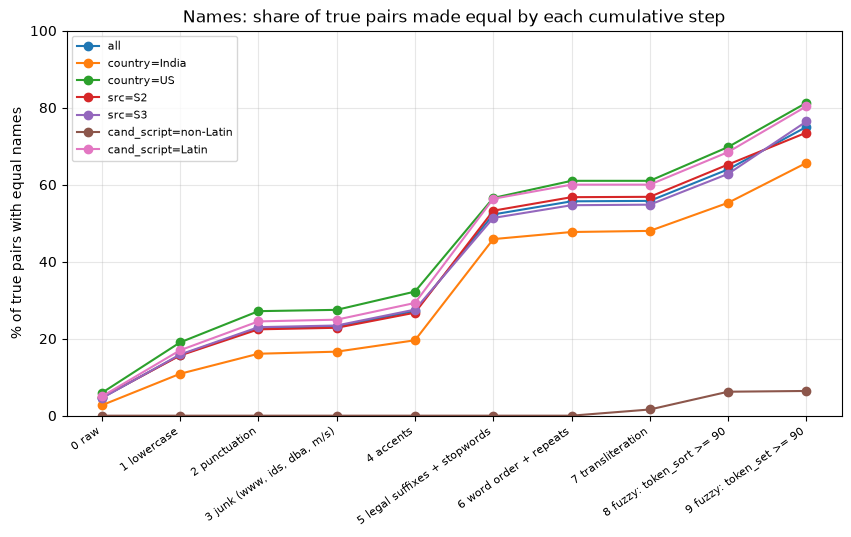

-> eda_outputs/04_name_staircase.png


In [14]:
resid = P.with_columns(ln=T["name"].gather(P["li"]), rn=T["name"].gather(P["ri"]), la=T["addr"].gather(P["li"]), ra=T["addr"].gather(P["ri"]))
resid_share = resid.group_by("country", "src").agg(pct_name_tset_below_80=(pl.col("name_tset") < 80).mean() * 100).sort("country", "src")
save_table(resid_share.with_columns(pl.col("pct_name_tset_below_80").round(2)), "04_name_residual_share")
save_table(resid.filter(pl.col("name_tset") < 80).sample(60, seed=SEED).select("country", "src", "name_tset", "ln", "rn", "la", "ra"), "04_name_residual_examples", show=30)

fig, ax = plt.subplots(figsize=(10, 5))
for col in [c for c in name_stair.columns if c != "step"]:
    ax.plot(range(name_stair.height), name_stair[col], marker="o", label=col)
ax.set_xticks(range(name_stair.height), name_stair["step"], rotation=35, ha="right", fontsize=8)
ax.set(ylabel="% of true pairs with equal names", title="Names: share of true pairs made equal by each cumulative step", ylim=(0, 100))
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
save_fig(fig, "04_name_staircase")

### Addresses
Same idea. Addresses often drop parts (no state, no street), so besides equality we also count one token set being contained in the other, and a fuzzy token_set score.

[address steps: 67.7s]
[address fuzzy: 2.6s]
-> eda_outputs/04_address_staircase.tsv  (9 rows)
┌───────────────────────────────┬───────┬───────────────┬────────────┬────────┬────────┬───────────────────┬───────────────────────┐
│ step                          ┆ all   ┆ country=India ┆ country=US ┆ src=S3 ┆ src=S2 ┆ cand_script=Latin ┆ cand_script=non-Latin │
│ ---                           ┆ ---   ┆ ---           ┆ ---        ┆ ---    ┆ ---    ┆ ---               ┆ ---                   │
│ str                           ┆ f64   ┆ f64           ┆ f64        ┆ f64    ┆ f64    ┆ f64               ┆ f64                   │
╞═══════════════════════════════╪═══════╪═══════════════╪════════════╪════════╪════════╪═══════════════════╪═══════════════════════╡
│ 0 raw                         ┆ 2.23  ┆ 2.14          ┆ 2.29       ┆ 4.31   ┆ 0.0    ┆ 2.4               ┆ 0.01                  │
│ 1 lowercase                   ┆ 7.41  ┆ 6.8           ┆ 7.82       ┆ 4.32   ┆ 10.72  ┆ 7.48              

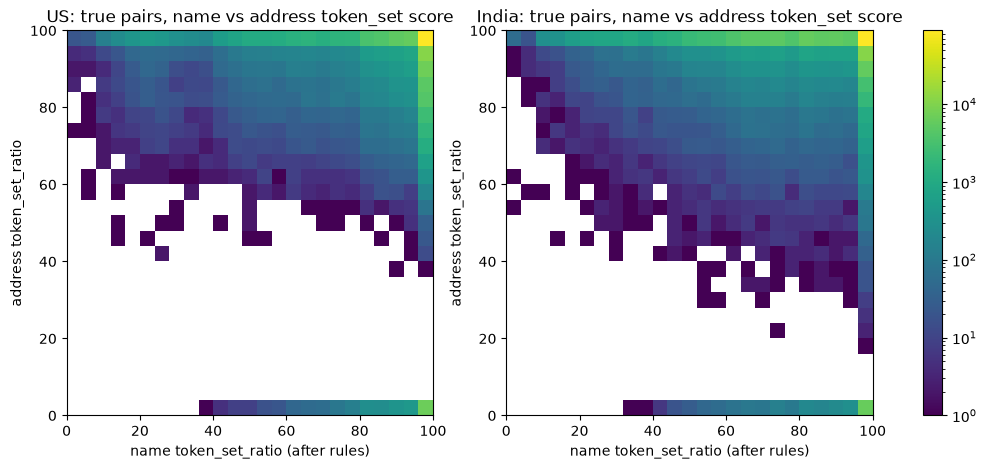

-> eda_outputs/04_name_vs_address_true_pairs.png


4361

In [15]:
with Timer("address steps"):
    ascii_addr = to_ascii("addr", pre_map=NATIVE_STATES)
    a_lower = lower(pl.col("addr"))
    a_punct = ws(punct(a_lower).str.replace_all(r"\b0+(\d)", "${1}"))
    a_abbr = word_map(a_punct, ABBR)
    a_region = word_map(a_abbr, {**US_STATES, **IN_STATES})
    a_translit = word_map(word_map(ws(punct(lower(ascii_addr)).str.replace_all(r"\b0+(\d)", "${1}")), ABBR), {**US_STATES, **IN_STATES})
    ADDR_STEPS = {
        "0 raw": pl.col("addr"),
        "1 lowercase": a_lower,
        "2 punctuation + leading zeros": a_punct,
        "3 abbreviations": a_abbr,
        "4 state names -> codes": a_region,
        "5 transliteration": a_translit,
        "6 component order": sort_tokens(a_translit),
    }
    addr_keys = T.select(**ADDR_STEPS)

aeq = {}
for step in ADDR_STEPS:
    k = addr_keys[step]
    aeq[step] = k.gather(li) == k.gather(ri)
fa = addr_keys["6 component order"]
la_t, ra_t = fa.gather(li).str.split(" "), fa.gather(ri).str.split(" ")
inter = la_t.list.set_intersection(ra_t).list.len()
nonempty = (fa.gather(li) != "") & (fa.gather(ri) != "")
aeq["7 one side contains the other"] = aeq["6 component order"] | (nonempty & ((inter == la_t.list.unique().list.len()) | (inter == ra_t.list.unique().list.len())))
with Timer("address fuzzy"):
    a_tset = process.cpdist(fa.gather(li).to_list(), fa.gather(ri).to_list(), scorer=fuzz.token_set_ratio, workers=-1)
aeq["8 fuzzy: token_set >= 90"] = aeq["7 one side contains the other"] | pl.Series(a_tset >= 90)
P = P.with_columns(addr_tset=pl.Series(a_tset), addr_empty=~nonempty)
addr_stair = staircase(aeq, "04_address_staircase")

# house numbers: first number in each address
hn = addr_keys["5 transliteration"]  # before sorting, so "first number" keeps its meaning
hn = hn.str.extract(r"\b(\d+)[a-z]?\b")
P = P.with_columns(hn_l=hn.gather(li), hn_r=hn.gather(ri))
hn_stats = P.group_by("country", "src").agg(
    house_no_equal_pct=(pl.col("hn_l") == pl.col("hn_r")).fill_null(False).mean() * 100,
    house_no_differs_pct=((pl.col("hn_l") != pl.col("hn_r")) & pl.col("hn_l").is_not_null() & pl.col("hn_r").is_not_null()).mean() * 100,
    house_no_missing_pct=(pl.col("hn_l").is_null() | pl.col("hn_r").is_null()).mean() * 100,
    addr_empty_pct=pl.col("addr_empty").mean() * 100,
).sort("country", "src")
save_table(hn_stats.with_columns(pl.selectors.float().round(2)), "04_house_number_agreement")

# name and address together: which pairs are hard on both?
both = P.group_by("country").agg(
    name_ok=(pl.col("name_tset") >= 90).mean() * 100,
    addr_ok=(pl.col("addr_tset") >= 90).mean() * 100,
    name_ok_or_addr_ok=((pl.col("name_tset") >= 90) | (pl.col("addr_tset") >= 90)).mean() * 100,
    both_below_70=((pl.col("name_tset") < 70) & (pl.col("addr_tset") < 70)).mean() * 100,
).sort("country")
save_table(both.with_columns(pl.selectors.float().round(2)), "04_name_vs_address_ok")
FINDINGS["pairs_name_or_addr_fuzzy90_pct"] = round(float(((P["name_tset"] >= 90) | (P["addr_tset"] >= 90)).mean() * 100), 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, c in zip(axes, ["US", "India"]):
    sub = P.filter(pl.col("country") == c).sample(200_000, seed=SEED)
    h = ax.hist2d(sub["name_tset"], sub["addr_tset"], bins=25, cmap="viridis", norm=matplotlib.colors.LogNorm())
    ax.set(title=f"{c}: true pairs, name vs address token_set score", xlabel="name token_set_ratio (after rules)", ylabel="address token_set_ratio")
fig.colorbar(h[3], ax=axes)
save_fig(fig, "04_name_vs_address_true_pairs")

# keep only the cleaned views used later and free the rest (the full-train tables are large)
name_lower = name_keys["1 lowercase"]
addr_clean = addr_keys["5 transliteration"]
addr_sorted = addr_keys["6 component order"]
del name_keys, addr_keys, resid, samp, diff, toks_l, toks_r, la_t, ra_t, inter, eq, aeq
gc.collect()

## 5. Exact-match rules, scored with the real metric on all of train
Each rule links an S1 to every same-country S2/S3 record with an identical key. Keys come from the section 4 clean-up. Keys shared by more than 50 S2/S3 records are skipped to keep the join bounded; linking those would be wrong most of the time anyway. The "unique S1 only" variant fires only when exactly one S1 in the country has the key.

In [16]:
RESULTS = []  # (section, approach, scope, metrics) collected for the decision table

K = T.select("idx", "entity_id", "source", "country").with_columns(
    name_key=final_name, addr_key=addr_sorted, house_no=hn
)
s1k = K.filter(pl.col("source") == "S1").rename({"entity_id": "s1_id"})
ck = K.filter(pl.col("source") != "S1").rename({"entity_id": "m_id"})
universe = s1_tr.select("s1_id")
truth = pairs.select("s1_id", "m_id")

RULES = {
    "name": ["name_key"],
    "name + house number": ["name_key", "house_no"],
    "name + full address": ["name_key", "addr_key"],
    "address only": ["addr_key"],
}
rows = [{"rule": "predict nothing", "variant": "-", **score(truth.head(0), truth, universe)}]
with Timer("exact rules"):
    for label, keys in RULES.items():
        on = ["country", *keys]
        a = s1k.drop_nulls(keys).filter(*[pl.col(k) != "" for k in keys])
        b = ck.drop_nulls(keys).filter(*[pl.col(k) != "" for k in keys])
        b = b.join(b.group_by(on).len().filter(pl.col("len") > 50), on=on, how="anti")
        pred = a.join(b, on=on).select("s1_id", "m_id")
        rows.append({"rule": label, "variant": "all S1 with the key", **score(pred, truth, universe)})
        uniq = a.group_by(on).len().filter(pl.col("len") == 1).drop("len")
        pred_u = a.join(uniq, on=on, how="semi").join(b, on=on).select("s1_id", "m_id")
        rows.append({"rule": label, "variant": "unique S1 only", **score(pred_u, truth, universe)})
rules_tbl = pl.DataFrame(rows)
save_table(rules_tbl.with_columns(pl.selectors.float().round(4)), "05_exact_rules")
best_rule = rules_tbl.sort("f05", descending=True).row(0, named=True)
RESULTS.append(("5", f"exact rule: {best_rule['rule']} ({best_rule['variant']})", "full train", best_rule))

# How many S1 share a cleaned name with another S1 of the same country? Those need the address to be told apart.
share = []
for label, keys in [("name", ["name_key"]), ("name + house number", ["name_key", "house_no"])]:
    g = s1k.drop_nulls(keys).group_by(["country", *keys]).len()
    share.append(
        s1k.join(g, on=["country", *keys], how="left").group_by("country").agg(
            key=pl.lit(label),
            s1_sharing_key_pct=(pl.col("len") > 1).mean() * 100,
            s1_in_groups_of_10plus_pct=(pl.col("len") >= 10).mean() * 100,
        )
    )
save_table(pl.concat(share).with_columns(pl.selectors.float().round(2)), "05_s1_name_collisions")
top_names = s1k.group_by("country", "name_key").len().sort("len", descending=True).head(25)
save_table(top_names, "05_most_shared_s1_names", show=15)

[exact rules: 14.4s]
-> eda_outputs/05_exact_rules.tsv  (9 rows)
┌─────────────────────┬─────────────────────┬────────┬───────────┬────────┬───────────────┬───────────┬────────────┐
│ rule                ┆ variant             ┆ f05    ┆ precision ┆ recall ┆ singleton_acc ┆ multi_f05 ┆ pred_pairs │
│ ---                 ┆ ---                 ┆ ---    ┆ ---       ┆ ---    ┆ ---           ┆ ---       ┆ ---        │
│ str                 ┆ str                 ┆ f64    ┆ f64       ┆ f64    ┆ f64           ┆ f64       ┆ i64        │
╞═════════════════════╪═════════════════════╪════════╪═══════════╪════════╪═══════════════╪═══════════╪════════════╡
│ predict nothing     ┆ -                   ┆ 0.0558 ┆ null      ┆ 0.0    ┆ 1.0           ┆ 0.0       ┆ 0          │
│ name                ┆ all S1 with the key ┆ 0.4469 ┆ 0.6218    ┆ 0.4574 ┆ 0.5135        ┆ 0.4525    ┆ 10159220   │
│ name                ┆ unique S1 only      ┆ 0.3822 ┆ 0.8552    ┆ 0.286  ┆ 0.8001        ┆ 0.3641    ┆ 2558950    │

## 6. Candidate search: recall vs cost of each search key
Recall is the share of true pairs that share the key. Cost is the number of S1 × S2/S3 comparisons the key produces (sum over key values of n_S1 × n_S2/S3, same country), shown per S1. Token keys can be limited to rare tokens by a document-frequency cap (df = number of same-country S2/S3 records containing the token).

[token keys: 25.3s]
-> eda_outputs/06_blocking_recall_cost.tsv  (19 rows)
┌───────────────────────────────────┬────────┬────────────┬────────────────────┐
│ key                               ┆ df_cap ┆ recall_pct ┆ comparisons_per_s1 │
│ ---                               ┆ ---    ┆ ---        ┆ ---                │
│ str                               ┆ str    ┆ f64        ┆ f64                │
╞═══════════════════════════════════╪════════╪════════════╪════════════════════╡
│ exact cleaned name                ┆ -      ┆ 55.792     ┆ 51.5               │
│ first cleaned-name token (sorted) ┆ -      ┆ 72.536     ┆ 13245.5            │
│ house number                      ┆ -      ┆ 70.219     ┆ 13347.8            │
│ house number + first 3 name chars ┆ -      ┆ 54.397     ┆ 87.5               │
│ name token                        ┆ 100    ┆ 20.469     ┆ 10.8               │
│ name token                        ┆ 1000   ┆ 44.25      ┆ 136.3              │
│ name token                       

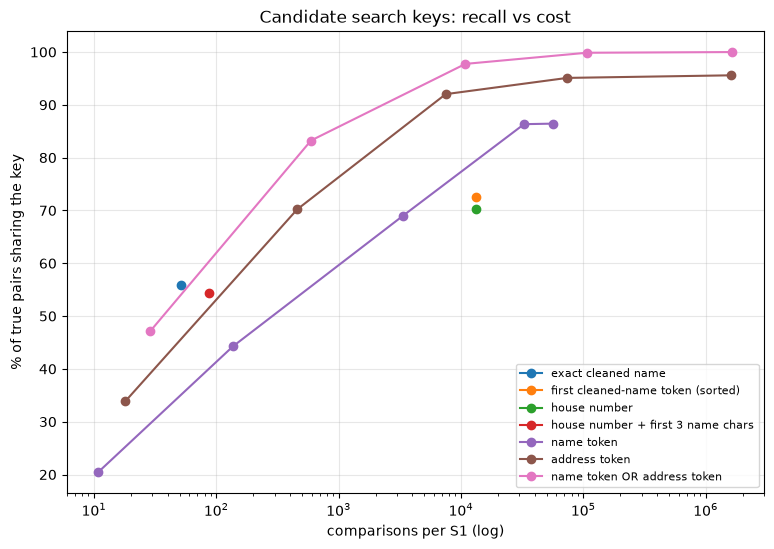

-> eda_outputs/06_blocking_recall_cost.png
-> eda_outputs/06_union_df1000_recall_by_group.tsv  (4 rows)
┌─────────┬─────┬────────────┐
│ country ┆ src ┆ recall_pct │
│ ---     ┆ --- ┆ ---        │
│ str     ┆ str ┆ f64        │
╞═════════╪═════╪════════════╡
│ India   ┆ S2  ┆ 86.877332  │
│ India   ┆ S3  ┆ 83.422825  │
│ US      ┆ S2  ┆ 81.617244  │
│ US      ┆ S3  ┆ 82.368794  │
└─────────┴─────┴────────────┘


In [19]:
countries = T["country"].unique().sort()
T_cid = T["country"].replace_strict(countries, pl.Series(range(len(countries)), dtype=pl.UInt8))
T_is_s1 = T["source"] == "S1"
P = P.with_columns(cid=T_cid.gather(li))
n_s1 = int(T_is_s1.sum())
DF_CAPS = [100, 1_000, 10_000, 100_000, None]


def token_table(keys: pl.Series) -> pl.DataFrame:
    """one row per (record, distinct token); country as a small int to keep memory down."""
    return (
        pl.DataFrame({"idx": T["idx"], "is_s1": T_is_s1, "cid": T_cid, "tok": keys.str.split(" ")})
        .explode("tok", empty_as_null=True).filter(pl.col("tok").is_not_null() & (pl.col("tok") != "")).unique(["idx", "tok"])
    )


def token_key_stats(tok: pl.DataFrame, keys: pl.Series, label: str):
    df = tok.filter(~pl.col("is_s1")).group_by("cid", "tok").agg(df=pl.len())
    n1 = tok.filter(pl.col("is_s1")).group_by("cid", "tok").agg(n1=pl.len())
    cost = n1.join(df, on=["cid", "tok"])
    shared = (
        pl.DataFrame({"pair": pl.int_range(P.height, eager=True, dtype=pl.UInt32), "cid": P["cid"],
                      "tok": keys.gather(li).str.split(" ").list.set_intersection(keys.gather(ri).str.split(" "))})
        .explode("tok", empty_as_null=True).drop_nulls("tok")
        .join(df, on=["cid", "tok"])
        .group_by("pair").agg(min_df=pl.col("df").min())
    )
    min_df = pl.DataFrame({"pair": pl.int_range(P.height, eager=True, dtype=pl.UInt32)}).join(shared, on="pair", how="left").sort("pair")["min_df"].cast(pl.Int64)  # Int64: compared with 10**12 below
    rows = []
    for cap in DF_CAPS:
        c = cap or 10**12
        comps = cost.filter(pl.col("df") <= c).select((pl.col("n1").cast(pl.Int64) * pl.col("df")).sum()).item()
        rows.append({"key": label, "df_cap": str(cap or "none"), "recall_pct": (min_df <= c).fill_null(False).mean() * 100, "comparisons_per_s1": comps / n_s1})
    return pl.DataFrame(rows), min_df, df


with Timer("token keys"):
    name_tok = token_table(final_name)
    addr_tok = token_table(addr_sorted)
    tbl_name, mindf_name, df_name = token_key_stats(name_tok, final_name, "name token")
    tbl_addr, mindf_addr, df_addr = token_key_stats(addr_tok, addr_sorted, "address token")

rows = []
for cap in DF_CAPS:
    c = cap or 10**12
    ok = (mindf_name <= c).fill_null(False) | (mindf_addr <= c).fill_null(False)
    cost = tbl_name.filter(pl.col("df_cap") == str(cap or "none"))["comparisons_per_s1"][0] + tbl_addr.filter(pl.col("df_cap") == str(cap or "none"))["comparisons_per_s1"][0]
    rows.append({"key": "name token OR address token", "df_cap": str(cap or "none"), "recall_pct": ok.mean() * 100, "comparisons_per_s1": cost})


def exact_key_stats(keys: pl.Series, label: str) -> dict:
    kk = pl.DataFrame({"is_s1": T_is_s1, "cid": T_cid, "k": keys}).filter(pl.col("k").is_not_null() & (pl.col("k") != ""))
    n1 = kk.filter(pl.col("is_s1")).group_by("cid", "k").agg(n1=pl.len())
    n2 = kk.filter(~pl.col("is_s1")).group_by("cid", "k").agg(n2=pl.len())
    c = n1.join(n2, on=["cid", "k"]).select((pl.col("n1").cast(pl.Int64) * pl.col("n2")).sum()).item()
    rec = (keys.gather(li) == keys.gather(ri)).fill_null(False).mean() * 100
    return {"key": label, "df_cap": "-", "recall_pct": rec, "comparisons_per_s1": c / n_s1}


exact_rows = [
    exact_key_stats(final_name, "exact cleaned name"),
    exact_key_stats(final_name.str.split(" ").list.first(), "first cleaned-name token (sorted)"),
    exact_key_stats(hn, "house number"),
    exact_key_stats(hn + "|" + final_name.str.slice(0, 3), "house number + first 3 name chars"),
]
blocking = pl.concat([pl.DataFrame(exact_rows), tbl_name, tbl_addr, pl.DataFrame(rows)])
save_table(blocking.with_columns(pl.col("recall_pct").round(3), pl.col("comparisons_per_s1").round(1)), "06_blocking_recall_cost")

fig, ax = plt.subplots(figsize=(9, 6))
for (key,), sub in blocking.group_by("key", maintain_order=True):
    ax.plot(sub["comparisons_per_s1"], sub["recall_pct"], marker="o", label=key)
ax.set(xscale="log", xlabel="comparisons per S1 (log)", ylabel="% of true pairs sharing the key", title="Candidate search keys: recall vs cost")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
save_fig(fig, "06_blocking_recall_cost")

# where does the cheap union (rare tokens, df <= 1,000) miss? by country and source
found = (mindf_name <= 1000).fill_null(False) | (mindf_addr <= 1000).fill_null(False)
save_table(P.select("country", "src").with_columns(found=found).group_by("country", "src").agg(recall_pct=pl.col("found").mean() * 100).sort("country", "src"), "06_union_df1000_recall_by_group")
FINDINGS["union_rare_token_df1000_recall_pct"] = round(float(found.mean() * 100), 3)

## 7. Fuzzy features on a sample: hand rules vs best single threshold vs gradient boosting
20,000 random train S1 (singletons included). Candidates come from shared rare tokens (name or address, df ≤ 1,000), scored by summed IDF, top 30 per S1 per source. Three groups are compared: true matches, near-miss non-matches (candidates that are wrong), and random same-country non-matches. All three approaches are scored with the per-S1 F0.5 on the same 20,000 S1, counting true matches that the candidate search missed.

In [20]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold

N_SAMPLE, TOPK, DF_BLOCK = 20_000, 30, 1_000
q = T.filter(pl.col("source") == "S1").sample(N_SAMPLE, seed=SEED).select(li="idx", country="country")
n_country = pl.DataFrame({"cid": T_cid, "is_s1": T_is_s1}).filter(~pl.col("is_s1")).group_by("cid").agg(N=pl.len())

with Timer("sample candidates"):
    parts = []
    for tok, dft in ((name_tok, df_name), (addr_tok, df_addr)):
        rare = dft.filter(pl.col("df") <= DF_BLOCK).join(n_country, on="cid").with_columns(idf=(pl.col("N") / pl.col("df")).log())
        qt = tok.join(q.select(idx="li"), on="idx", how="semi").join(rare, on=["cid", "tok"]).select(li="idx", cid="cid", tok="tok", idf="idf")
        ct = tok.filter(~pl.col("is_s1")).join(qt.select("cid", "tok").unique(), on=["cid", "tok"], how="semi").select(ri="idx", cid="cid", tok="tok")
        parts.append(qt.join(ct, on=["cid", "tok"]).group_by("li", "ri").agg(s=pl.col("idf").sum()))
    cand = pl.concat(parts).group_by("li", "ri").agg(block_score=pl.col("s").sum())
    cand = cand.with_columns(src=T["source"].gather(cand["ri"]))
    cand = cand.with_columns(block_rank=pl.col("block_score").rank("ordinal", descending=True).over("li", "src")).filter(pl.col("block_rank") <= TOPK)
truth_idx = P.select("li", "ri").join(q, on="li", how="semi")
cand = cand.join(truth_idx.with_columns(label=pl.lit(1)), on=["li", "ri"], how="left").with_columns(pl.col("label").fill_null(0))
print(f"candidates: {cand.height:,} ({cand.height / N_SAMPLE:.0f} per S1) | true pairs of sample: {truth_idx.height:,} | found: {cand['label'].sum() / truth_idx.height * 100:.2f}%")

rand = pl.concat([
    T.filter((pl.col("source") != "S1") & (pl.col("country") == c)).sample(5 * sub.height, seed=SEED).select(ri="idx", src="source")
    .with_columns(li=pl.Series(np.repeat(sub["li"].to_numpy(), 5)))
    for (c,), sub in q.group_by("country")
]).join(truth_idx, on=["li", "ri"], how="anti").with_columns(label=pl.lit(0), block_score=pl.lit(None, pl.Float64), block_rank=pl.lit(None, pl.UInt32))

[sample candidates: 3.5s]
candidates: 1,022,022 (51 per S1) | true pairs of sample: 68,943 | found: 65.95%


[features: 3.1s]
-> eda_outputs/07_feature_medians_and_auc.tsv  (15 rows)
┌───────────────────┬───────────┬────────┬────────────┬───────────────────────┐
│ column            ┆ near-miss ┆ random ┆ true match ┆ AUC true vs near-miss │
│ ---               ┆ ---       ┆ ---    ┆ ---        ┆ ---                   │
│ str               ┆ f64       ┆ f64    ┆ f64        ┆ f64                   │
╞═══════════════════╪═══════════╪════════╪════════════╪═══════════════════════╡
│ name_ratio        ┆ 35.0      ┆ 30.769 ┆ 100.0      ┆ 0.956                 │
│ name_token_sort   ┆ 35.0      ┆ 30.769 ┆ 100.0      ┆ 0.956                 │
│ name_token_set    ┆ 35.897    ┆ 30.769 ┆ 100.0      ┆ 0.945                 │
│ name_partial      ┆ 44.444    ┆ 40.0   ┆ 100.0      ┆ 0.946                 │
│ name_jaro_winkler ┆ 55.266    ┆ 52.265 ┆ 100.0      ┆ 0.945                 │
│ name_raw_ratio    ┆ 37.143    ┆ 32.0   ┆ 87.5       ┆ 0.907                 │
│ addr_token_set    ┆ 46.667    ┆ 36.036 ┆ 100

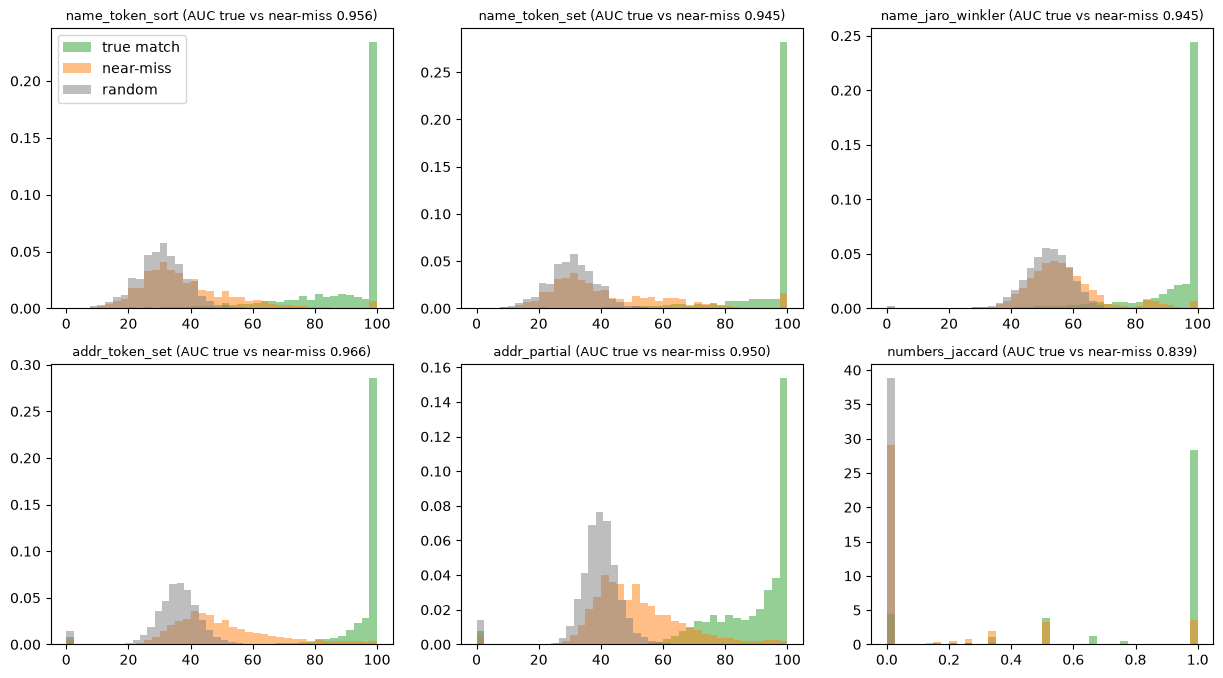

-> eda_outputs/07_feature_distributions.png


In [21]:
nums = addr_clean.str.extract_all(r"\d+")
nonlatin = T["name"].str.contains(NONLATIN_RE)


def features(df: pl.DataFrame) -> pl.DataFrame:
    l, r = df["li"], df["ri"]
    fl, fr_ = final_name.gather(l).to_list(), final_name.gather(r).to_list()
    al, ar = addr_clean.gather(l).to_list(), addr_clean.gather(r).to_list()
    asl, asr = addr_sorted.gather(l).to_list(), addr_sorted.gather(r).to_list()
    cd = lambda a, b, s: process.cpdist(a, b, scorer=s, workers=-1)
    hl, hr = hn.gather(l), hn.gather(r)
    nl, nr = nums.gather(l), nums.gather(r)
    inter = nl.list.set_intersection(nr).list.len()
    union_ = nl.list.set_union(nr).list.len()
    return df.with_columns(
        name_ratio=pl.Series(cd(fl, fr_, fuzz.ratio)),
        name_token_sort=pl.Series(cd(fl, fr_, fuzz.token_sort_ratio)),
        name_token_set=pl.Series(cd(fl, fr_, fuzz.token_set_ratio)),
        name_partial=pl.Series(cd(fl, fr_, fuzz.partial_ratio)),
        name_jaro_winkler=pl.Series(cd(fl, fr_, JaroWinkler.normalized_similarity) * 100),
        name_raw_ratio=pl.Series(cd(name_lower.gather(l).to_list(), name_lower.gather(r).to_list(), fuzz.ratio)),
        addr_token_set=pl.Series(cd(asl, asr, fuzz.token_set_ratio)),
        addr_ratio=pl.Series(cd(al, ar, fuzz.ratio)),
        addr_partial=pl.Series(cd(al, ar, fuzz.partial_ratio)),
        house_no_equal=pl.when(hl.is_null() | hr.is_null()).then(-1).when(hl == hr).then(1).otherwise(0),
        numbers_jaccard=pl.when(union_ > 0).then(inter / union_).otherwise(None),
        numbers_conflict=((nl.list.len() > 0) & (nr.list.len() > 0) & (inter == 0)).cast(pl.Int8),
        addr_empty=((addr_sorted.gather(l) == "") | (addr_sorted.gather(r) == "")).cast(pl.Int8),
        cand_nonlatin=nonlatin.gather(r).cast(pl.Int8),
        name_len_ratio=(final_name.gather(l).str.len_chars().cast(pl.Float64) / final_name.gather(r).str.len_chars().clip(1)).clip(0, 5),
    )


with Timer("features"):
    feat = features(cand).with_columns(group=pl.when(pl.col("label") == 1).then(pl.lit("true match")).otherwise(pl.lit("near-miss")))
    feat_rand = features(rand).with_columns(group=pl.lit("random"))
FEATS = [c for c in feat.columns if c.startswith(("name_", "addr_", "house_", "numbers_", "cand_"))]

allf = pl.concat([feat.drop("block_score", "block_rank"), feat_rand.drop("block_score", "block_rank")], how="diagonal_relaxed")
summary = allf.group_by("group").agg(*[pl.col(f).median().alias(f) for f in FEATS]).sort("group")
auc = {f: roc_auc_score(feat["label"], feat[f].fill_null(-1)) for f in FEATS}
summary = pl.concat([summary.with_columns(pl.all().exclude("group").cast(pl.Float64)), pl.DataFrame({"group": ["AUC true vs near-miss"], **{f: [auc[f]] for f in FEATS}})])
save_table(summary.with_columns(pl.selectors.float().round(3)).transpose(include_header=True, column_names="group"), "07_feature_medians_and_auc")

show = ["name_token_sort", "name_token_set", "name_jaro_winkler", "addr_token_set", "addr_partial", "numbers_jaccard"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, f in zip(axes.flat, show):
    for g, color in [("true match", "tab:green"), ("near-miss", "tab:orange"), ("random", "tab:gray")]:
        v = allf.filter(pl.col("group") == g)[f].drop_nulls().to_numpy()
        ax.hist(v, bins=40, density=True, alpha=0.5, label=g, color=color)
    ax.set_title(f"{f} (AUC true vs near-miss {auc[f]:.3f})", fontsize=9)
axes[0, 0].legend()
save_fig(fig, "07_feature_distributions")

In [22]:
Ts = T.select("idx", "entity_id")
s_universe = q.join(Ts, left_on="li", right_on="idx").select(s1_id="entity_id")
s_truth = truth_idx.join(Ts, left_on="li", right_on="idx").join(Ts, left_on="ri", right_on="idx").select(s1_id="entity_id", m_id="entity_id_right")
feat = feat.join(Ts, left_on="li", right_on="idx").join(Ts, left_on="ri", right_on="idx").rename({"entity_id": "s1_id", "entity_id_right": "m_id"})


def score_mask(mask) -> dict:
    return score(feat.filter(mask).select("s1_id", "m_id"), s_truth, s_universe)


model_rows = []
hand = ((pl.col("name_token_set") >= 90) & (pl.col("addr_token_set") >= 80)) | ((pl.col("name_token_sort") == 100) & (pl.col("house_no_equal") == 1))
model_rows.append({"approach": "hand rule: (name_set>=90 & addr_set>=80) or (name_sort==100 & house no equal)", **score_mask(hand)})

best = None
for f in FEATS:
    for t in np.unique(np.quantile(feat[f].drop_nulls().to_numpy(), np.linspace(0.5, 0.995, 40))):
        r = score_mask(pl.col(f) >= t)
        if best is None or r["f05"] > best[2]["f05"]:
            best = (f, t, r)
model_rows.append({"approach": f"best single threshold: {best[0]} >= {best[1]:.2f}", **best[2]})

with Timer("gradient boosting (5-fold, grouped by S1)"):
    X = (
        feat.with_columns(rel_block=pl.col("block_score") / pl.col("block_score").max().over("li"))
        .select(FEATS + ["block_score", "block_rank", "rel_block"]).cast(pl.Float32).to_numpy()
    )
    y = feat["label"].to_numpy()
    oof = np.zeros(len(y))
    for tr_i, va_i in GroupKFold(n_splits=5).split(X, y, groups=feat["li"].to_numpy()):
        m = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1, random_state=SEED).fit(X[tr_i], y[tr_i])
        oof[va_i] = m.predict_proba(X[va_i])[:, 1]
feat = feat.with_columns(p=pl.Series(oof))
gbm = max(((t, score_mask(pl.col("p") >= t)) for t in np.arange(0.1, 0.96, 0.05)), key=lambda x: x[1]["f05"])
model_rows.append({"approach": f"gradient boosting, OOF prob >= {gbm[0]:.2f}", **gbm[1]})
model_rows.append({"approach": "ceiling: every true match the candidate search found", **score_mask(pl.col("label") == 1)})
models = pl.DataFrame(model_rows)
save_table(models.with_columns(pl.selectors.float().round(4)), "07_rules_vs_threshold_vs_gbm")
for r in model_rows:
    RESULTS.append(("7", r["approach"], f"{N_SAMPLE:,} S1 sample", r))
FINDINGS["sample_gbm_f05"] = round(gbm[1]["f05"], 4)

for (c,), sub_u in q.join(Ts, left_on="li", right_on="idx").group_by("country"):
    u = sub_u.select(s1_id="entity_id")
    print(c, "GBM F0.5:", round(score(feat.filter(pl.col("p") >= gbm[0]).select("s1_id", "m_id"), s_truth, u)["f05"], 4))

[gradient boosting (5-fold, grouped by S1): 5.8s]
-> eda_outputs/07_rules_vs_threshold_vs_gbm.tsv  (4 rows)
┌─────────────────────────────────────────────────────────────────────────┬────────┬───────────┬────────┬───────────────┬───────────┬────────────┐
│ approach                                                                ┆ f05    ┆ precision ┆ recall ┆ singleton_acc ┆ multi_f05 ┆ pred_pairs │
│ ---                                                                     ┆ ---    ┆ ---       ┆ ---    ┆ ---           ┆ ---       ┆ ---        │
│ str                                                                     ┆ f64    ┆ f64       ┆ f64    ┆ f64           ┆ f64       ┆ i64        │
╞═════════════════════════════════════════════════════════════════════════╪════════╪═══════════╪════════╪═══════════════╪═══════════╪════════════╡
│ hand rule: (name_set>=90 & addr_set>=80) or (name_sort==100 & house no… ┆ 0.5631 ┆ 0.7908    ┆ 0.4937 ┆ 0.5142        ┆ 0.5771    ┆ 41829      │
│ best sin

## 8. Embeddings vs char n-gram TF-IDF (optional, needs PyTorch + sentence-transformers)
Question: do multilingual embeddings find the true matches that plain text matching misses, especially Indic-script names?

Setup: 2,000 India S1 that have matches. The search pool is all their true S2/S3 records plus 50,000 random India S2/S3 records. For each true pair: the rank of the true record among the pool for its S1, by cosine similarity. Results are split by candidate script and by "hard" pairs (cleaned-name token_set < 80 after section 4).

Model: `intfloat/multilingual-e5-small` (MIT, 118M parameters, ~470 MB download on first run). Set `RUN_EMBEDDINGS = False` to skip.

/mnt/vaultb/Soham/MLCSoham/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


queries 2,000 | pool 57,218 | true pairs 7,313 | non-Latin candidates 1,299


Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 10823.52it/s]


[embeddings on cuda: 20.7s]
-> eda_outputs/08_embeddings_vs_tfidf.tsv  (20 rows)
┌───────────────────────────────────────┬───────────────────────────────────┬──────┬──────────┬───────────┬───────────┐
│ method                                ┆ pairs                             ┆ n    ┆ recall@1 ┆ recall@10 ┆ recall@50 │
│ ---                                   ┆ ---                               ┆ ---  ┆ ---      ┆ ---       ┆ ---       │
│ str                                   ┆ str                               ┆ i64  ┆ f64      ┆ f64       ┆ f64       │
╞═══════════════════════════════════════╪═══════════════════════════════════╪══════╪══════════╪═══════════╪═══════════╡
│ TF-IDF char 2-4, raw name             ┆ all                               ┆ 7313 ┆ 26.64    ┆ 69.08     ┆ 74.68     │
│ TF-IDF char 2-4, raw name             ┆ candidate Latin                   ┆ 6014 ┆ 32.39    ┆ 83.87     ┆ 90.59     │
│ TF-IDF char 2-4, raw name             ┆ candidate non-Latin               ┆ 1

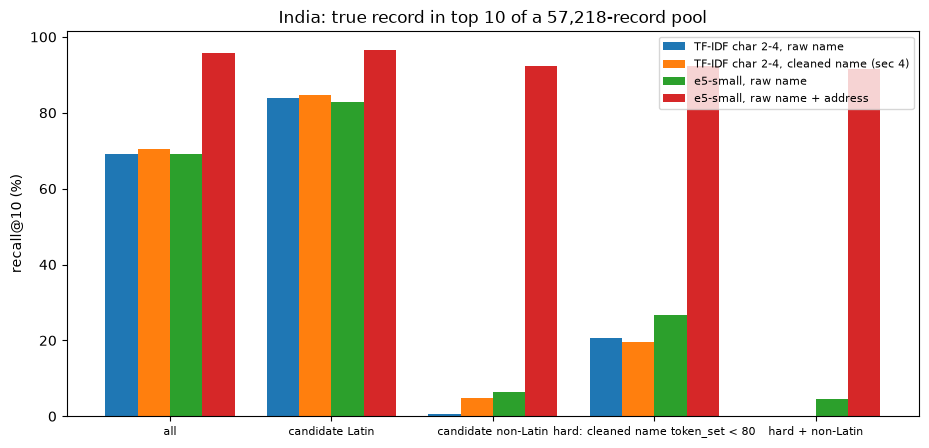

-> eda_outputs/08_embeddings_vs_tfidf.png


In [23]:
RUN_EMBEDDINGS = True
EMB_MODEL = "intfloat/multilingual-e5-small"
N_QUERY, N_DISTRACT = 2_000, 50_000

from sklearn.feature_extraction.text import TfidfVectorizer

try:
    import torch
    from sentence_transformers import SentenceTransformer
    HAVE_TORCH = True
except ImportError:
    HAVE_TORCH = False

india_s1 = T.filter((pl.col("source") == "S1") & (pl.col("country") == "India")).select(li="idx")
qs = india_s1.join(P.select("li").unique(), on="li", how="semi").sample(N_QUERY, seed=SEED)
tp = P.join(qs, on="li", how="semi").select("li", "ri", "cand_script", "name_tset")
pool = pl.concat([
    tp.select(idx="ri"),
    T.filter((pl.col("source") != "S1") & (pl.col("country") == "India")).sample(N_DISTRACT, seed=SEED).select("idx"),
]).unique(maintain_order=True).with_row_index("pos")
qs = qs.with_row_index("qpos")
tp = tp.join(qs, on="li").join(pool.rename({"idx": "ri"}), on="ri")
print(f"queries {qs.height:,} | pool {pool.height:,} | true pairs {tp.height:,} | non-Latin candidates {(tp['cand_script'] == 'non-Latin').sum():,}")


def true_ranks(Q, D) -> np.ndarray:
    """rank (0 = top) of each true pair's record among the pool, by dot product. Q, D: row-normalized."""
    ranks = np.empty(tp.height, dtype=np.int64)
    qpos, dpos = tp["qpos"].to_numpy(), tp["pos"].to_numpy()
    for start in range(0, Q.shape[0], 250):
        rows = np.arange(start, min(start + 250, Q.shape[0]))
        sims = Q[rows] @ D.T
        sims = sims.toarray() if hasattr(sims, "toarray") else np.asarray(sims)
        sel = np.where((qpos >= rows[0]) & (qpos <= rows[-1]))[0]
        s_true = sims[qpos[sel] - rows[0], dpos[sel]]
        ranks[sel] = (sims[qpos[sel] - rows[0]] > s_true[:, None]).sum(axis=1)
    return ranks


q_raw, d_raw = T["name"].gather(qs["li"]).to_list(), T["name"].gather(pool["idx"]).to_list()
q_cln, d_cln = final_name.gather(qs["li"]).to_list(), final_name.gather(pool["idx"]).to_list()
q_full = (T["name"] + ", " + T["addr"]).gather(qs["li"]).to_list()
d_full = (T["name"] + ", " + T["addr"]).gather(pool["idx"]).to_list()

method_ranks = {}
for label, (qt_, dt_) in {"TF-IDF char 2-4, raw name": (q_raw, d_raw), "TF-IDF char 2-4, cleaned name (sec 4)": (q_cln, d_cln)}.items():
    vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), sublinear_tf=True, dtype=np.float32).fit(dt_ + qt_)
    method_ranks[label] = true_ranks(vec.transform(qt_), vec.transform(dt_))

if RUN_EMBEDDINGS and HAVE_TORCH:
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    model = SentenceTransformer(EMB_MODEL, device=dev)
    enc = lambda xs: model.encode(["query: " + x for x in xs], batch_size=512, normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=False)
    with Timer(f"embeddings on {dev}"):
        method_ranks["e5-small, raw name"] = true_ranks(enc(q_raw), enc(d_raw))
        method_ranks["e5-small, raw name + address"] = true_ranks(enc(q_full), enc(d_full))
else:
    print("embeddings skipped (RUN_EMBEDDINGS is False or torch / sentence-transformers not installed)")

groups = {
    "all": pl.lit(True),
    "candidate Latin": pl.col("cand_script") == "Latin",
    "candidate non-Latin": pl.col("cand_script") == "non-Latin",
    "hard: cleaned name token_set < 80": pl.col("name_tset") < 80,
    "hard + non-Latin": (pl.col("name_tset") < 80) & (pl.col("cand_script") == "non-Latin"),
}
emb_rows = []
for m, rk in method_ranks.items():
    frame = tp.with_columns(rank=pl.Series(rk))
    for g, cond in groups.items():
        sub = frame.filter(cond)
        emb_rows.append({"method": m, "pairs": g, "n": sub.height,
                         **{f"recall@{k}": (sub["rank"] < k).mean() * 100 if sub.height else None for k in (1, 10, 50)}})
emb_tbl = pl.DataFrame(emb_rows)
save_table(emb_tbl.with_columns(pl.selectors.float().round(2)), "08_embeddings_vs_tfidf", show=25)

fig, ax = plt.subplots(figsize=(11, 5))
gl = list(groups)
w = 0.8 / len(method_ranks)
for i, m in enumerate(method_ranks):
    vals = [emb_tbl.filter((pl.col("method") == m) & (pl.col("pairs") == g))["recall@10"][0] for g in gl]
    ax.bar(np.arange(len(gl)) + i * w, vals, w, label=m)
ax.set_xticks(np.arange(len(gl)) + w * (len(method_ranks) - 1) / 2, gl, fontsize=8)
ax.set(ylabel="recall@10 (%)", title=f"India: true record in top 10 of a {pool.height:,}-record pool")
ax.legend(fontsize=8)
save_fig(fig, "08_embeddings_vs_tfidf")
FINDINGS["retrieval_recall@10_hard_nonlatin"] = {
    r["method"]: round(r["recall@10"], 2) for r in emb_rows if r["pairs"] == "hard + non-Latin" and r["recall@10"] is not None
}

## 9. Duplicates inside S2/S3, and ID / row-order leak checks
One S1 usually has several S2 and S3 matches, so S2 and S3 contain their own duplicates. If those duplicates look more like each other than like the S1, linking them to each other lets an easy match pull in a hard one.

In [24]:
sub_s1 = P.select("li").unique().sample(300_000, seed=SEED)
pp = P.join(sub_s1, on="li", how="semi").select("li", "ri", "src", "name_tset", "addr_tset")
dup = pp.join(pp, on="li", suffix="_y").filter(pl.col("ri") != pl.col("ri_y"))
with Timer("within-entity similarity"):
    dup = dup.with_columns(
        dd_name=pl.Series(process.cpdist(final_name.gather(dup["ri"]).to_list(), final_name.gather(dup["ri_y"]).to_list(), scorer=fuzz.token_set_ratio, workers=-1)),
        dd_addr=pl.Series(process.cpdist(addr_sorted.gather(dup["ri"]).to_list(), addr_sorted.gather(dup["ri_y"]).to_list(), scorer=fuzz.token_set_ratio, workers=-1)),
    )
dup_stats = dup.filter(pl.col("ri") < pl.col("ri_y")).group_by("src", "src_y").agg(
    pairs=pl.len(),
    dup_name_set_ge90_pct=(pl.col("dd_name") >= 90).mean() * 100,
    dup_addr_set_ge90_pct=(pl.col("dd_addr") >= 90).mean() * 100,
    s1_to_x_name_set_ge90_pct=(pl.col("name_tset") >= 90).mean() * 100,
    s1_to_x_addr_set_ge90_pct=(pl.col("addr_tset") >= 90).mean() * 100,
).sort("src", "src_y")
save_table(dup_stats.with_columns(pl.selectors.float().round(2)), "09_within_entity_similarity")

# rescue: a pair (S1, x) that is hard on the name, where another true match y is easy (S1-y name >= 90) and y looks like x
hard = pp.filter(pl.col("name_tset") < 80)
rescued = dup.filter((pl.col("name_tset") < 80) & (pl.col("name_tset_y") >= 90) & ((pl.col("dd_name") >= 90) | (pl.col("dd_addr") >= 90))).select("li", "ri").unique()
resc = pl.DataFrame({
    "hard pairs (name token_set < 80)": [hard.height],
    "rescued via another match of the same S1": [rescued.height],
    "rescued_pct": [rescued.height / max(hard.height, 1) * 100],
})
save_table(resc, "09_duplicate_rescue")
FINDINGS["hard_name_pairs_rescued_by_duplicates_pct"] = round(resc["rescued_pct"][0], 2)

# exact duplicates inside one source: same cleaned name + address, but owned by different S1s (or unmatched)
owner = pairs.select("m_id", "s1_id")
exd = (
    K.filter(pl.col("source") != "S1").rename({"entity_id": "m_id"}).join(owner, on="m_id", how="left")
    .group_by("source", "country", "name_key", "addr_key").agg(n=pl.len(), owners=pl.col("s1_id").n_unique(), has_unmatched=pl.col("s1_id").is_null().any())
    .filter(pl.col("n") >= 2)
    .group_by("source").agg(
        dup_groups=pl.len(),
        same_owner_pct=((pl.col("owners") == 1) & ~pl.col("has_unmatched")).mean() * 100,
        different_owners_pct=(pl.col("owners") > 1).mean() * 100,
        includes_unmatched_pct=pl.col("has_unmatched").mean() * 100,
    )
)
save_table(exd.with_columns(pl.selectors.float().round(2)), "09_exact_duplicates_owner")

[within-entity similarity: 2.2s]
-> eda_outputs/09_within_entity_similarity.tsv  (3 rows)
┌─────┬───────┬─────────┬───────────────────────┬───────────────────────┬───────────────────────────┬───────────────────────────┐
│ src ┆ src_y ┆ pairs   ┆ dup_name_set_ge90_pct ┆ dup_addr_set_ge90_pct ┆ s1_to_x_name_set_ge90_pct ┆ s1_to_x_addr_set_ge90_pct │
│ --- ┆ ---   ┆ ---     ┆ ---                   ┆ ---                   ┆ ---                       ┆ ---                       │
│ str ┆ str   ┆ u32     ┆ f64                   ┆ f64                   ┆ f64                       ┆ f64                       │
╞═════╪═══════╪═════════╪═══════════════════════╪═══════════════════════╪═══════════════════════════╪═══════════════════════════╡
│ S2  ┆ S2    ┆ 376604  ┆ 60.42                 ┆ 84.35                 ┆ 74.43                     ┆ 85.67                     │
│ S2  ┆ S3    ┆ 1000743 ┆ 59.77                 ┆ 65.97                 ┆ 73.5                      ┆ 85.65                     │


### Leak checks
If IDs or row positions carried the answer (matched IDs numerically close, matched rows near each other, unmatched records grouped at the end of a file), a model could learn that instead of the text. Each statistic is shown next to a random-pair baseline.

-> eda_outputs/09_leak_checks.tsv  (9 rows)
┌───────────────────────────────────────────────────┬──────────────┬─────────────────┐
│ check                                             ┆ value        ┆ random_baseline │
│ ---                                               ┆ ---          ┆ ---             │
│ str                                               ┆ f64          ┆ f64             │
╞═══════════════════════════════════════════════════╪══════════════╪═════════════════╡
│ Spearman(S1 id number, matched id number)         ┆ 0.0001       ┆ -0.0003         │
│ Spearman(S1 row position, matched row position)   ┆ 0.0001       ┆ -0.0003         │
│ median |row position diff|, S1 vs matched         ┆ 0.2929       ┆ 0.2931          │
│ median |row position diff|, two matches of one S1 ┆ 0.2934       ┆ 0.2928          │
│ mean row position of matched S2/S3                ┆ 0.5          ┆ 0.5             │
│ mean row position of unmatched S2/S3              ┆ 0.5          ┆ 0.5             │

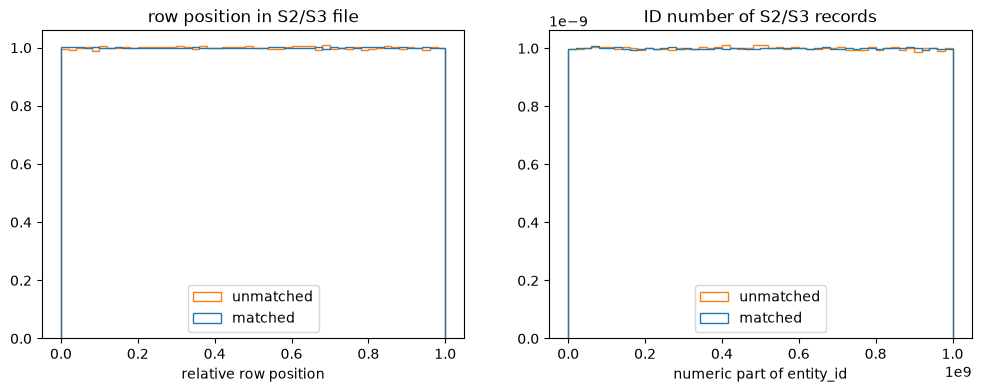

-> eda_outputs/09_leak_checks.png


In [25]:
Tl = T.with_columns(
    num=pl.col("entity_id").str.extract(r"-(\d+)$").cast(pl.Int64),
    pos=(pl.col("idx") - pl.col("idx").min().over("source")) / pl.len().over("source"),
)
num, pos = Tl["num"], Tl["pos"]
rnd_r = pl.Series(RNG.choice(P["ri"].to_numpy(), P.height))


def spearman(a: pl.Series, b: pl.Series) -> float:
    return pl.DataFrame({"a": a.rank(), "b": b.rank()}).select(pl.corr("a", "b")).item()


matched = pl.Series(T["idx"].is_in(P["ri"].implode()))
cands = Tl.with_columns(matched=matched).filter(pl.col("source") != "S1")
gt_pos = gt_raw.with_row_index("gt_row").select("gt_row", s1_id="source1_entity_id").join(T.select(s1_id="entity_id", idx="idx"), on="s1_id")
leak = pl.DataFrame([
    {"check": "Spearman(S1 id number, matched id number)", "value": spearman(num.gather(li), num.gather(ri)), "random_baseline": spearman(num.gather(li), num.gather(rnd_r))},
    {"check": "Spearman(S1 row position, matched row position)", "value": spearman(pos.gather(li), pos.gather(ri)), "random_baseline": spearman(pos.gather(li), pos.gather(rnd_r))},
    {"check": "median |row position diff|, S1 vs matched", "value": (pos.gather(li) - pos.gather(ri)).abs().median(), "random_baseline": (pos.gather(li) - pos.gather(rnd_r)).abs().median()},
    {"check": "median |row position diff|, two matches of one S1", "value": (pos.gather(dup["ri"]) - pos.gather(dup["ri_y"])).abs().median(), "random_baseline": (pos.gather(dup["ri"]) - pos.gather(pl.Series(RNG.choice(P["ri"].to_numpy(), dup.height)))).abs().median()},
    {"check": "mean row position of matched S2/S3", "value": cands.filter(pl.col("matched"))["pos"].mean(), "random_baseline": 0.5},
    {"check": "mean row position of unmatched S2/S3", "value": cands.filter(~pl.col("matched"))["pos"].mean(), "random_baseline": 0.5},
    {"check": "median id number, matched S2/S3", "value": float(cands.filter(pl.col("matched"))["num"].median()), "random_baseline": float(cands["num"].median())},
    {"check": "median id number, unmatched S2/S3", "value": float(cands.filter(~pl.col("matched"))["num"].median()), "random_baseline": float(cands["num"].median())},
    {"check": "Spearman(ground-truth row, S1 file row)", "value": spearman(gt_pos["gt_row"].cast(pl.Float64), gt_pos["idx"].cast(pl.Float64)), "random_baseline": 0.0},
])
save_table(leak.with_columns(pl.selectors.float().round(4)), "09_leak_checks")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist([cands.filter(pl.col("matched"))["pos"].to_numpy(), cands.filter(~pl.col("matched"))["pos"].to_numpy()], bins=50, density=True, label=["matched", "unmatched"], histtype="step")
axes[0].set(title="row position in S2/S3 file", xlabel="relative row position")
axes[0].legend()
axes[1].hist([cands.filter(pl.col("matched"))["num"].to_numpy(), cands.filter(~pl.col("matched"))["num"].to_numpy()], bins=50, density=True, label=["matched", "unmatched"], histtype="step")
axes[1].set(title="ID number of S2/S3 records", xlabel="numeric part of entity_id")
axes[1].legend()
save_fig(fig, "09_leak_checks")

## 10. Decision table
Every approach scored above, ranked by per-S1 macro F0.5. Rows from section 5 are on all of train; rows from section 7 are on the 20,000-S1 sample (same metric, so they are comparable up to sample noise). The ceiling row is the best any matcher could reach with that candidate search. Section 8's retrieval recall is listed separately because it is not an F0.5.

Keep in mind: test has an estimated ~40% unmatched S2/S3 records vs ~26% in train (section 3), so precision on test will be lower than these train numbers.

In [26]:
dec = (
    pl.DataFrame([
        {"section": s, "approach": a, "scope": sc, "macro_f05": r["f05"], "precision": r["precision"], "recall": r["recall"],
         "singleton_acc": r["singleton_acc"], "multi_match_f05": r["multi_f05"], "pred_pairs": r["pred_pairs"]}
        for s, a, sc, r in RESULTS
    ])
    .sort("macro_f05", descending=True)
    .with_row_index("rank", offset=1)
)
save_table(dec.with_columns(pl.selectors.float().round(4)), "10_decision_table")

if "emb_tbl" in globals():
    retr = emb_tbl.filter(pl.col("pairs").is_in(["all", "hard + non-Latin"])).pivot(on="pairs", index="method", values="recall@10")
    save_table(retr.with_columns(pl.selectors.float().round(2)), "10_retrieval_recall10_summary")

FINDINGS["decision_table_top"] = dec.head(5).select("approach", "macro_f05").rows()
write_text("findings.json", json.dumps(FINDINGS, indent=2, ensure_ascii=False, default=str))
print(json.dumps(FINDINGS, indent=2, ensure_ascii=False, default=str))

-> eda_outputs/10_decision_table.tsv  (5 rows)
┌──────┬─────────┬─────────────────────────────────────────────────────────────────────────┬──────────────────┬───────────┬───────────┬────────┬───────────────┬─────────────────┬────────────┐
│ rank ┆ section ┆ approach                                                                ┆ scope            ┆ macro_f05 ┆ precision ┆ recall ┆ singleton_acc ┆ multi_match_f05 ┆ pred_pairs │
│ ---  ┆ ---     ┆ ---                                                                     ┆ ---              ┆ ---       ┆ ---       ┆ ---    ┆ ---           ┆ ---             ┆ ---        │
│ u32  ┆ str     ┆ str                                                                     ┆ str              ┆ f64       ┆ f64       ┆ f64    ┆ f64           ┆ f64             ┆ i64        │
╞══════╪═════════╪═════════════════════════════════════════════════════════════════════════╪══════════════════╪═══════════╪═══════════╪════════╪═══════════════╪═════════════════╪═══════